# Medical Question Answering on PubMedQA:
## Analysing Text Representations and Classifier Design

**Group 16**
**EMATM0067 – Introduction to AI and Text Analytics**
**University of Bristol**

---

**Objective:** This notebook analyses how different text representations (Axis 1) and AI classifiers (Axis 2) affect performance on the PubMedQA biomedical question-answering task. We follow the evaluation protocol from Jin et al. (2019) with a 500/500 CV/test split and macro-F1 as the primary metric.

## Table of Contents

1. **Environment Setup** — Library imports and runtime verification
2. **Dataset Loading and Exploration** — JSON parsing, label distribution, text statistics
3. **Preprocessing and Feature Engineering** — Text cleaning, input variants, handcrafted features
4. **Data Splitting Strategy** — PubMedQA 500/500 split with 10-fold CV
5. **Baseline Model** — TF-IDF + Logistic Regression
6. **Axis 1: Text Representation Experiments** — Q-only, Q+Ctx, Q+Ctx+Ans, BioBERT embeddings
7. **Axis 2: Classifier Design Experiments** — Tuned LR, SVM, NB, SMOTE, Ensemble, Transformers
8. **Addressing the Maybe-Class Challenge** — Threshold tuning, Focal Loss, Hierarchical, LoRA
9. **Model Comparison and Final Selection** — Full ranking, statistical significance
10. **Error Analysis** — Qualitative examples, cluster analysis, error overlap
11. **Answer Quality Prediction** — Exploratory baseline analysis
12. **Final Predictions Export** — `predictions.json` generation
13. **Summary and Key Findings**

## 1. Environment Setup

We import all libraries required for machine learning, NLP, and deep learning, and verify GPU availability for transformer fine-tuning.

In [1]:
import os
import re
import json
import math
import random
import warnings
from collections import Counter, defaultdict
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_auc_score
)

try:
    import torch
    from transformers import (
        AutoTokenizer,
        AutoModel,
        AutoModelForSequenceClassification
    )
    TRANSFORMERS_AVAILABLE = True
except Exception:
    TRANSFORMERS_AVAILABLE = False

try:
    from sentence_transformers import SentenceTransformer
    SBERT_OK = True
except Exception:
    SBERT_OK = False

TRANSFORMERS_OK = TRANSFORMERS_AVAILABLE

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

if TRANSFORMERS_AVAILABLE:
    torch.manual_seed(RANDOM_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_SEED)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

print("All main libraries imported successfully.")
print(f"Random seed set to {RANDOM_SEED}")
print(f"Transformers available: {TRANSFORMERS_AVAILABLE}")
print(f"SentenceTransformers available: {SBERT_OK}")

All main libraries imported successfully.
Random seed set to 42
Transformers available: True
SentenceTransformers available: True


In [2]:
!pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
print("imbalanced-learn installed and imported.")

imbalanced-learn installed and imported.


All core libraries loaded successfully. PyTorch with CUDA support is available, enabling GPU-accelerated transformer fine-tuning.

## 2. Dataset Loading and Exploration

### 2.1 Loading the JSON Dataset

We load the PubMedQA dataset from disk and inspect a single record to understand the data schema.

In [3]:
DATA_PATH = "/content/data/ori_pqal.json"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print(f"Total records: {len(data)}")

first_key = list(data.keys())[0]
print(f"\nExample PMID: {first_key}")
print(json.dumps(data[first_key], indent=2)[:800])

Total records: 1000

Example PMID: 21645374
{
  "QUESTION": "Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?",
  "CONTEXTS": [
    "Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants.",
    "The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madaga


The dataset contains 1,000 records keyed by PubMed ID (PMID). Each record has a biomedical question, a list of context sentences from the abstract, a long-form answer, and a final decision label (*yes*, *no*, or *maybe*).

### 2.2 Converting to a Pandas DataFrame

We convert the raw JSON into a structured DataFrame and check for missing values.

In [4]:
rows = []
for pmid, info in data.items():
    contexts = info.get("CONTEXTS", [])
    rows.append({
        "pmid": pmid,
        "question": info.get("QUESTION", ""),
        "context_list": contexts,
        "context": " ".join(contexts) if isinstance(contexts, list) else str(contexts),
        "long_answer": info.get("LONG_ANSWER", ""),
        "label": str(info.get("final_decision", "")).lower().strip()
    })

df = pd.DataFrame(rows)
print(f"\nDataFrame shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")


DataFrame shape: (1000, 6)
Columns: ['pmid', 'question', 'context_list', 'context', 'long_answer', 'label']

Missing values:
pmid            0
question        0
context_list    0
context         0
long_answer     0
label           0
dtype: int64


The JSON converts to a 1,000-row, 6-column DataFrame with zero missing values.

### 2.3 Label Distribution

We examine how the three target labels are distributed across the dataset.

In [5]:
print(f"\nLabel distribution:")
print(df["label"].value_counts())


Label distribution:
label
yes      552
no       338
maybe    110
Name: count, dtype: int64


The label distribution reveals a pronounced class imbalance: *yes* accounts for 552 samples (55.2%), *no* for 338 (33.8%), and *maybe* for only 110 (11.0%). The minority *maybe* class represents uncertain or inconclusive biomedical evidence, and classifiers tend to ignore it in favour of the majority *yes* class.

### 2.4 Text Length Statistics

We compute word counts for questions, contexts, and long answers to understand the scale of each text field.

In [6]:
df["question_len"] = df["question"].str.split().str.len()
df["context_len"] = df["context"].str.split().str.len()
df["long_answer_len"] = df["long_answer"].str.split().str.len()
df["num_contexts"] = df["context_list"].apply(lambda x: len(x) if isinstance(x, list) else 0)

print(f"Feature columns added: question_len, context_len, long_answer_len, num_contexts")

Feature columns added: question_len, context_len, long_answer_len, num_contexts


Four numeric metadata features are appended: word counts for the question, concatenated context, and long answer, plus the number of context sentences per sample.

### 2.5 Data Exploration Visualisations

We produce visualisation panels showing label distribution, text length histograms by label, context sentence counts, and boxplots to identify structural patterns.

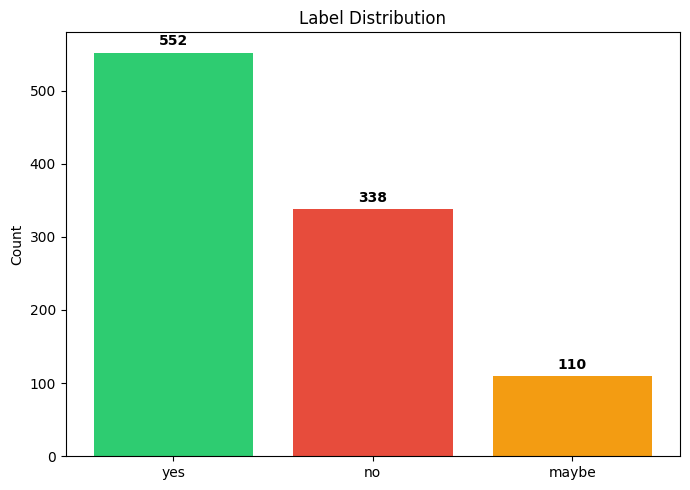

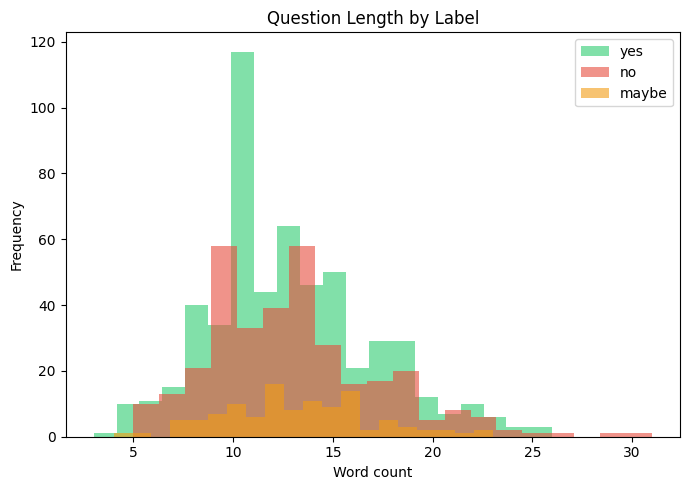

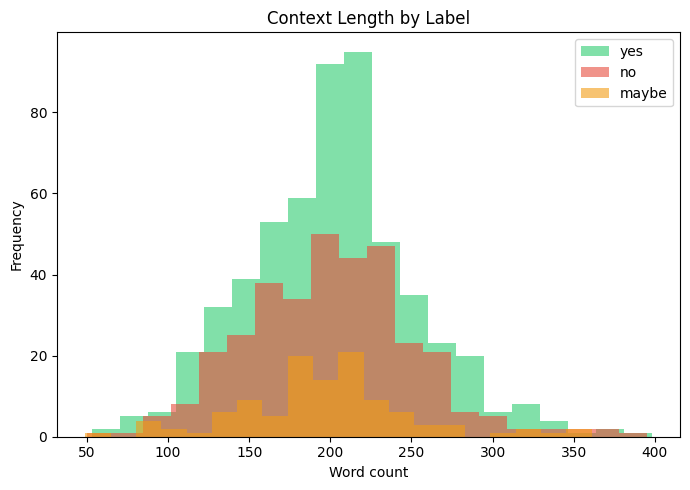

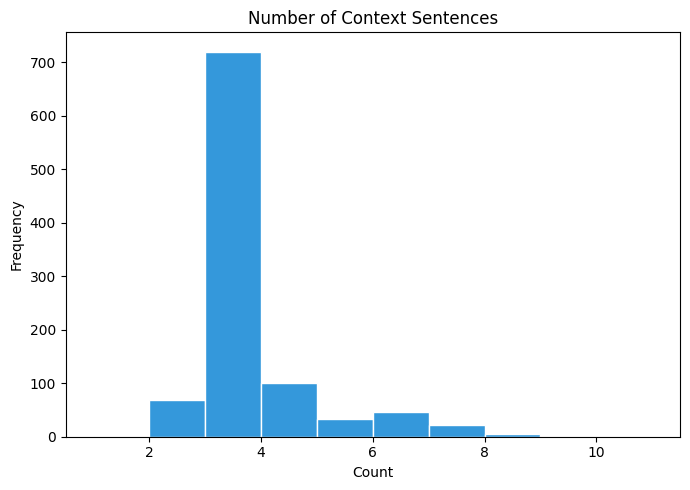

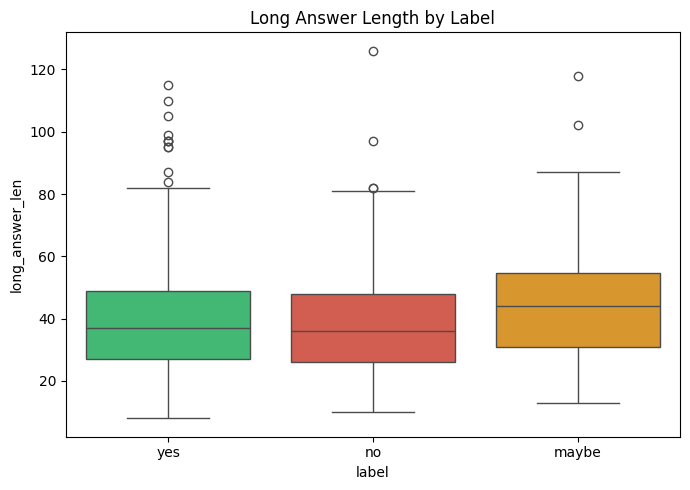

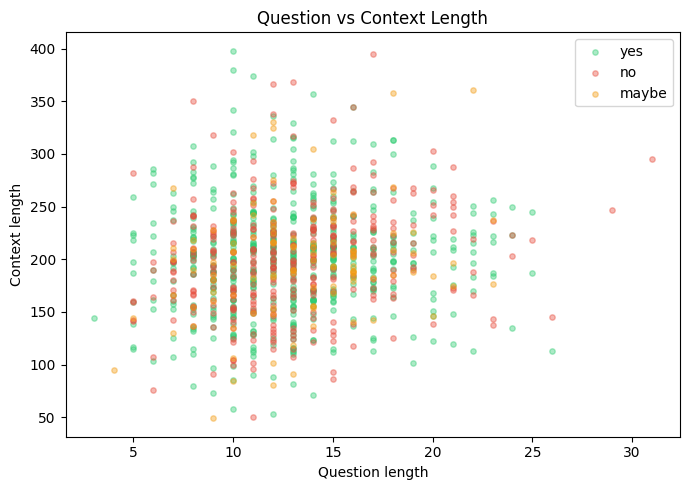

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

save_dir = "visualizations"
os.makedirs(save_dir, exist_ok=True)

colors = {"yes": "#2ecc71", "no": "#e74c3c", "maybe": "#f39c12"}

plt.figure(figsize=(7, 5))
label_counts = df["label"].value_counts()
plt.bar(label_counts.index, label_counts.values,
        color=[colors.get(lab, "#3498db") for lab in label_counts.index])
plt.title("Label Distribution")
plt.ylabel("Count")

for i, (lab, cnt) in enumerate(zip(label_counts.index, label_counts.values)):
    plt.text(i, cnt + 10, str(cnt), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_1_label_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
for lab in ["yes", "no", "maybe"]:
    subset = df[df["label"] == lab]["question_len"]
    plt.hist(subset, bins=20, alpha=0.6, label=lab, color=colors[lab])

plt.title("Question Length by Label")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_2_question_length_by_label.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
for lab in ["yes", "no", "maybe"]:
    subset = df[df["label"] == lab]["context_len"]
    plt.hist(subset, bins=20, alpha=0.6, label=lab, color=colors[lab])

plt.title("Context Length by Label")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_3_context_length_by_label.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(df["num_contexts"], bins=range(1, 12), color="#3498db", edgecolor="white")
plt.title("Number of Context Sentences")
plt.xlabel("Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_4_num_context_sentences.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df,
    x="label",
    y="long_answer_len",
    order=["yes", "no", "maybe"],
    palette=[colors["yes"], colors["no"], colors["maybe"]]
)
plt.title("Long Answer Length by Label")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_5_long_answer_length_by_label.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
for lab in ["yes", "no", "maybe"]:
    subset = df[df["label"] == lab]
    plt.scatter(
        subset["question_len"],
        subset["context_len"],
        alpha=0.4,
        label=lab,
        color=colors[lab],
        s=15
    )

plt.title("Question vs Context Length")
plt.xlabel("Question length")
plt.ylabel("Context length")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_6_question_vs_context_length.png"), dpi=300, bbox_inches="tight")
plt.show()

The visualisations confirm the severe class imbalance. Context texts are substantially longer than questions, and the number of context sentences varies across records, suggesting that document structure may carry signal.

### 2.6 Descriptive Statistics Summary

We summarise the text length distributions with standard descriptive statistics.

In [8]:
print("\nDescriptive statistics:")
display(df[["question_len", "context_len", "long_answer_len", "num_contexts"]].describe().round(1))


Descriptive statistics:


,question_len,context_len,long_answer_len,num_contexts
count,1000.0,1000.0,1000.0,1000.0
mean,12.9,200.2,39.7,3.4
std,4.1,51.8,17.2,1.1
min,3.0,49.0,8.0,1.0
25%,10.0,166.8,27.0,3.0
50%,13.0,200.5,37.0,3.0
75%,15.0,228.0,49.0,3.0
max,31.0,398.0,126.0,9.0


Questions average 12.9 words (std = 4.1), contexts average 200.2 words (std = 51.8), and long answers average 39.7 words (std = 17.2). The number of context sentences per record averages 3.4. Contexts are roughly 15× longer than questions, motivating the truncation strategies used in transformer fine-tuning.

## 3. Preprocessing and Feature Engineering

### 3.1 Text Cleaning

We define a cleaning function that lowercases text, collapses whitespace, and removes irregular punctuation, then apply it to all text fields.

In [9]:
df_model = df.copy()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^\w\s\-\?\.,:;/%()]", " ", text)
    return text.strip()

df_model["question_clean"] = df_model["question"].apply(clean_text)
df_model["context_clean"] = df_model["context"].apply(clean_text)
df_model["long_answer_clean"] = df_model["long_answer"].apply(clean_text)

print(f"Text cleaning complete. Columns: {[c for c in df_model.columns if 'clean' in c]}")

Text cleaning complete. Columns: ['question_clean', 'context_clean', 'long_answer_clean']


Text cleaning is applied uniformly to questions, contexts, and long answers to reduce vocabulary noise.

### 3.2 Input Variants and Label Encoding

We construct three input text variants for the Axis 1 comparison: question only (Q), question + context (Q+Ctx), and question + context + long answer (Q+Ctx+Ans). Labels are encoded as integers: no=0, maybe=1, yes=2.

In [10]:
df_model["text_q_only"] = "question: " + df_model["question_clean"]
df_model["text_q_ctx"] = (
    "question: " + df_model["question_clean"]
    + " context: " + df_model["context_clean"]
)
df_model["text_q_ctx_ans"] = (
    "question: " + df_model["question_clean"]
    + " context: " + df_model["context_clean"]
    + " answer: " + df_model["long_answer_clean"]
)

label2id = {"no": 0, "maybe": 1, "yes": 2}
id2label = {0: "no", 1: "maybe", 2: "yes"}
df_model["label_id"] = df_model["label"].map(label2id)
df_model["question_len"] = df_model["question_clean"].apply(lambda x: len(x.split()))
df_model["context_len"] = df_model["context_clean"].apply(lambda x: len(x.split()))
df_model["long_answer_len"] = df_model["long_answer_clean"].apply(lambda x: len(x.split()))
df_model["num_contexts"] = df_model["context_list"].apply(lambda x: len(x) if isinstance(x, list) else 1)

assert df_model["label_id"].isna().sum() == 0, "Unmapped labels found!"

print(f"Input variants created. Shape: {df_model.shape}")
print(f"Label distribution: {df_model['label_id'].value_counts().sort_index().to_dict()}")

Input variants created. Shape: (1000, 17)
Label distribution: {0: 338, 1: 110, 2: 552}


Two sequence formats are created. The `text_*` variants use explicit prefixes (`question:`, `context:`, `answer:`), while the `q_*` variants concatenate segments with `[SEP]` tokens. This keeps the input construction flexible across classical and transformer experiments.

### 3.3 Handcrafted NLP Features

We engineer binary indicator features using only question- and context-based information: negation, causation, comparison, association, risk language, context evidence strength, and context hedging. We avoid features derived from the long answer in this exploratory quality-prediction section to reduce information leakage.

In [11]:
df_model["has_negation"] = df_model["question_clean"].apply(
    lambda x: int(any(w in x.split() for w in ["no", "not", "without", "lack", "absence"]))
)
df_model["has_causal"] = df_model["question_clean"].apply(
    lambda x: int(any(w in x for w in ["cause", "effect", "impact", "influence", "affect", "lead to"]))
)
df_model["has_comparison"] = df_model["question_clean"].apply(
    lambda x: int(any(w in x for w in ["compar", "differ", "versus", "vs", "better", "worse"]))
)
df_model["has_association"] = df_model["question_clean"].apply(
    lambda x: int(any(w in x for w in ["associat", "correlat", "relat", "link"]))
)
df_model["has_risk"] = df_model["question_clean"].apply(
    lambda x: int("risk" in x)
)
df_model["context_evidence_strength"] = df_model["context_clean"].apply(
    lambda x: int(any(w in x for w in ["significant", "strongly", "clearly", "demonstrated"]))
)
df_model["context_hedging"] = df_model["context_clean"].apply(
    lambda x: int(any(w in x for w in ["may", "might", "suggest", "possibly", "further study", "inconclusive"]))
)

print("Preprocessing complete")
print(f"Shape: {df_model.shape}")
print(f"Label distribution:\n{df_model['label_id'].value_counts().sort_index()}")
print(f"\nSample cleaned text (first row):")
print(df_model["text_q_ctx"].iloc[0][:200])

Preprocessing complete
Shape: (1000, 24)
Label distribution:
label_id
0    338
1    110
2    552
Name: count, dtype: int64

Sample cleaned text (first row):
question: do mitochondria play a role in remodelling lace plant leaves during programmed cell death? context: programmed cell death (pcd) is the regulated death of cells within an organism. the lace p


Seven binary handcrafted features are created using keyword matching from the question and context only. These capture linguistic cues such as hedging words (e.g., *may*, *suggest*, *possibly*) that may help distinguish the *maybe* class from definitive *yes*/*no* answers, without relying on long-answer-derived information.

## 4. Data Splitting Strategy

We follow the PubMedQA evaluation protocol described by Jin et al. (2019): the 1,000 labelled samples are split into 500 for cross-validation and 500 for final testing, with stratified sampling to preserve label proportions. The split is reproduced programmatically with random seed 0.


### 4.1 Split Functions

We implement the stratified splitting logic from the PubMedQA repository with random seed 0. The split is reconstructed programmatically rather than loading the exact PMID list from the repository, so the resulting split is protocol-consistent but not guaranteed identical to the repository's precomputed split.

In [12]:
random.seed(0)

def split_dataset(dataset_pmids, labels, fold):
    add = lambda x: reduce(lambda a, b: a + b, x)

    label2pmids = defaultdict(list)
    for pmid, lab in zip(dataset_pmids, labels):
        label2pmids[lab].append(pmid)

    label2splits = {}
    for lab, pmids in label2pmids.items():
        random.shuffle(pmids)
        num_all = len(pmids)
        num_split = math.ceil(num_all / fold)
        splits = []
        for i in range(fold):
            if i == fold - 1:
                splits.append(pmids[i * num_split:])
            else:
                splits.append(pmids[i * num_split: (i + 1) * num_split])
        label2splits[lab] = splits

    output = []
    for i in range(fold):
        fold_pmids = add([label2splits[lab][i] for lab in sorted(label2splits.keys())])
        output.append(fold_pmids)

    if len(output[-1]) != len(output[0]):
        for i in range(fold - 1):
            if len(output[i]) > len(output[-1]):
                picked = random.choice(output[i])
                output[-1].append(picked)
                output[i].remove(picked)

    return output

all_pmids = df_model["pmid"].tolist()
all_labels = df_model["label"].tolist()

two_halves = split_dataset(all_pmids, all_labels, 2)
cv_pmids = set(two_halves[0])
test_pmids = set(two_halves[1])

print(f"CV set:   {len(cv_pmids)} samples")
print(f"Test set: {len(test_pmids)} samples")

cv_df = df_model[df_model["pmid"].isin(cv_pmids)].copy()
test_df = df_model[df_model["pmid"].isin(test_pmids)].copy()

print(f"\nCV label distribution:")
print(cv_df["label"].value_counts())
print(f"\nTest label distribution:")
print(test_df["label"].value_counts())

CV set:   500 samples
Test set: 500 samples

CV label distribution:
label
yes      276
no       169
maybe     55
Name: count, dtype: int64

Test label distribution:
label
yes      276
no       169
maybe     55
Name: count, dtype: int64


### 4.1a Split Verification

We verify the reconstructed 500/500 split: correct sizes, unique PMIDs, and no overlap between sets.

In [13]:
assert len(cv_df) == 500, f"CV set should be 500, got {len(cv_df)}"
assert len(test_df) == 500, f"Test set should be 500, got {len(test_df)}"
assert cv_df["pmid"].nunique() == 500, "CV PMIDs not unique"
assert test_df["pmid"].nunique() == 500, "Test PMIDs not unique"
assert set(cv_df["pmid"]).isdisjoint(set(test_df["pmid"])), "CV/Test overlap detected!"

print("500 CV / 500 test split verified correctly.")

500 CV / 500 test split verified correctly.


The split is verified: 500 CV and 500 test samples with identical label distributions (276 yes, 169 no, 55 maybe in each half) and zero PMID overlap.

### 4.2 Ten-Fold Cross-Validation Splits

We divide the 500 CV samples into 10 stratified folds. For each fold, one subset (~50 samples) serves as validation while the remaining nine (~450 samples) are used for training.

In [14]:
cv_pmid_list = cv_df["pmid"].tolist()
cv_label_list = cv_df["label"].tolist()

random.seed(0)
ten_folds = split_dataset(cv_pmid_list, cv_label_list, 10)

print("10-Fold CV split sizes:")
for i, fold in enumerate(ten_folds):
    fold_df = cv_df[cv_df["pmid"].isin(fold)]
    dist = fold_df["label"].value_counts().to_dict()
    print(f"  Fold {i}: {len(fold)} samples — {dist}")

pmid_to_fold = {}
for fold_idx, fold_pmids in enumerate(ten_folds):
    for pmid in fold_pmids:
        pmid_to_fold[pmid] = fold_idx

cv_df["fold"] = cv_df["pmid"].map(pmid_to_fold)

print(f"\nTotal CV samples with fold assignment: {cv_df['fold'].notna().sum()}")

10-Fold CV split sizes:
  Fold 0: 50 samples — {'yes': 28, 'no': 16, 'maybe': 6}
  Fold 1: 50 samples — {'yes': 28, 'no': 17, 'maybe': 5}
  Fold 2: 50 samples — {'yes': 28, 'no': 16, 'maybe': 6}
  Fold 3: 50 samples — {'yes': 28, 'no': 17, 'maybe': 5}
  Fold 4: 50 samples — {'yes': 27, 'no': 17, 'maybe': 6}
  Fold 5: 50 samples — {'yes': 27, 'no': 17, 'maybe': 6}
  Fold 6: 50 samples — {'yes': 28, 'no': 16, 'maybe': 6}
  Fold 7: 50 samples — {'yes': 28, 'no': 16, 'maybe': 6}
  Fold 8: 50 samples — {'yes': 28, 'no': 16, 'maybe': 6}
  Fold 9: 50 samples — {'yes': 26, 'no': 21, 'maybe': 3}

Total CV samples with fold assignment: 500


Each fold contains approximately 50 samples with proportional label representation, ensuring all three classes appear in every fold.

### 4.3 Feature Array Extraction

We extract labels, PMIDs, and text arrays for the test set and prepare all three input variants for the CV folds.

In [15]:
if "question_clean" in df_model.columns:
    q_col = "question_clean"
else:
    q_col = "question"

if "context_clean" in df_model.columns:
    c_col = "context_clean"
else:
    c_col = "context"

if "long_answer_clean" in df_model.columns:
    a_col = "long_answer_clean"
else:
    a_col = "long_answer"

for frame in [cv_df, test_df]:
    frame["q_only"] = frame[q_col].fillna("")
    frame["q_ctx"] = (
        frame[q_col].fillna("") + " [SEP] " +
        frame[c_col].fillna("")
    )
    frame["q_ctx_ans"] = (
        frame[q_col].fillna("") + " [SEP] " +
        frame[c_col].fillna("") + " [SEP] " +
        frame[a_col].fillna("")
    )

y_test = test_df["label_id"].values
pmid_test = test_df["pmid"].values

X_test_qonly = test_df["q_only"].tolist()
X_test_qctx = test_df["q_ctx"].tolist()
X_test_qctxans = test_df["q_ctx_ans"].tolist()

y_cv = cv_df["label_id"].values
X_cv_qonly = cv_df["q_only"].tolist()
X_cv_qctx = cv_df["q_ctx"].tolist()
X_cv_qctxans = cv_df["q_ctx_ans"].tolist()

print("Test set arrays extracted:")
print(f"  y_test shape: {y_test.shape}")
print(f"  Test label dist: {pd.Series(y_test).map(id2label).value_counts().to_dict()}")
print(f"\nCV set arrays extracted:")
print(f"  y_cv shape: {y_cv.shape}")
print(f"  CV label dist: {pd.Series(y_cv).map(id2label).value_counts().to_dict()}")

Test set arrays extracted:
  y_test shape: (500,)
  Test label dist: {'yes': 276, 'no': 169, 'maybe': 55}

CV set arrays extracted:
  y_cv shape: (500,)
  CV label dist: {'yes': 276, 'no': 169, 'maybe': 55}


Feature arrays are extracted for both sets across all three input variants. The test arrays remain fixed throughout all experiments.

## 5. Baseline Model: TF-IDF + Logistic Regression

We establish a baseline using TF-IDF features with balanced Logistic Regression, evaluated under the 10-fold CV protocol.

### 5.1 Ten-Fold CV Evaluation Helper

We define a reusable function that runs the 10-fold CV protocol on any scikit-learn pipeline, fitting TF-IDF only on training data within each fold.

In [16]:
def evaluate_10fold_cv(make_pipeline_fn, cv_df, text_col, test_texts, y_test,
                      n_folds=10, return_fold_preds=False):
    fold_accs = []
    fold_f1s = []
    fold_preds_all = {}

    for fold_idx in range(n_folds):
        val_mask = cv_df["fold"] == fold_idx
        train_mask = ~val_mask

        X_tr = cv_df.loc[train_mask, text_col].tolist()
        y_tr = cv_df.loc[train_mask, "label_id"].values
        X_val = cv_df.loc[val_mask, text_col].tolist()
        y_val = cv_df.loc[val_mask, "label_id"].values

        pipe = make_pipeline_fn()
        pipe.fit(X_tr, y_tr)
        val_preds = pipe.predict(X_val)

        fold_accs.append(accuracy_score(y_val, val_preds))
        fold_f1s.append(f1_score(y_val, val_preds, average="macro"))

        if return_fold_preds:
            fold_preds_all[fold_idx] = (y_val, val_preds)

    final_pipe = make_pipeline_fn()
    X_cv_all = cv_df[text_col].tolist()
    y_cv_all = cv_df["label_id"].values
    final_pipe.fit(X_cv_all, y_cv_all)
    test_preds = final_pipe.predict(test_texts)

    test_acc = accuracy_score(y_test, test_preds)
    test_f1 = f1_score(y_test, test_preds, average="macro")

    result = {
        "cv_acc_mean": np.mean(fold_accs),
        "cv_acc_std": np.std(fold_accs),
        "cv_f1_mean": np.mean(fold_f1s),
        "cv_f1_std": np.std(fold_f1s),
        "test_acc": test_acc,
        "test_f1": test_f1,
        "preds": test_preds,
        "final_pipeline": final_pipe,
    }
    if return_fold_preds:
        result["fold_preds"] = fold_preds_all
    return result

print("10-fold CV evaluation helper defined.")
print("Key design: TF-IDF is fitted INSIDE each fold to prevent data leakage.")

10-fold CV evaluation helper defined.
Key design: TF-IDF is fitted INSIDE each fold to prevent data leakage.


The `evaluate_10fold_cv` helper enforces leakage-free evaluation. A factory function creates a fresh pipeline for each fold to prevent state leakage.

### 5.2 Baseline Pipeline

We build a pipeline that vectorises text using TF-IDF (unigrams and bigrams, up to 30,000 features) and classifies with balanced Logistic Regression.

In [17]:
def make_baseline_pipe():
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True, stop_words="english",
            ngram_range=(1, 2), max_features=30000
        )),
        ("clf", LogisticRegression(
            max_iter=2000, class_weight="balanced",
            random_state=RANDOM_SEED, C=1.0
        ))
    ])

baseline_res = evaluate_10fold_cv(
    make_baseline_pipe, cv_df, "q_ctx", X_test_qctx, y_test
)

print("=" * 60)
print("BASELINE: TF-IDF (1,2)-grams + Logistic Regression")
print("=" * 60)
print(f"10-Fold CV Accuracy : {baseline_res['cv_acc_mean']:.4f} ± {baseline_res['cv_acc_std']:.4f}")
print(f"10-Fold CV Macro-F1 : {baseline_res['cv_f1_mean']:.4f} ± {baseline_res['cv_f1_std']:.4f}")
print(f"Test Accuracy       : {baseline_res['test_acc']:.4f}")
print(f"Test Macro-F1       : {baseline_res['test_f1']:.4f}")
print(f"\n{classification_report(y_test, baseline_res['preds'], target_names=['no','maybe','yes'], zero_division=0)}")

BASELINE: TF-IDF (1,2)-grams + Logistic Regression
10-Fold CV Accuracy : 0.5260 ± 0.0754
10-Fold CV Macro-F1 : 0.3549 ± 0.0569
Test Accuracy       : 0.5120
Test Macro-F1       : 0.3558

              precision    recall  f1-score   support

          no       0.39      0.30      0.34       169
       maybe       0.23      0.05      0.09        55
         yes       0.57      0.73      0.64       276

    accuracy                           0.51       500
   macro avg       0.40      0.36      0.36       500
weighted avg       0.47      0.51      0.48       500



The baseline achieves a **10-fold CV macro-F1 of 0.3549 ± 0.0569** and a **test macro-F1 of 0.3558**. Test accuracy is 51.2%, which is below the majority-class baseline of 55.2%, showing why accuracy is misleading for PubMedQA and why macro-F1 is the appropriate primary metric.

**Why Accuracy is Misleading:** With *yes* comprising 55.2% of samples, a trivial all-*yes* classifier achieves ~55% accuracy. Macro-F1 weights all three classes equally, making it the appropriate metric for this imbalanced task.

### 5.3 Baseline Confusion Matrix

We plot a confusion matrix to visualise the baseline's failure modes.

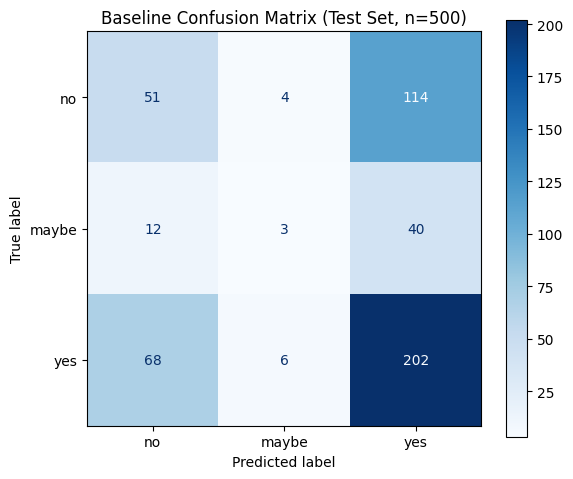

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, baseline_res["preds"],
    display_labels=["no", "maybe", "yes"], ax=ax, cmap="Blues"
)
ax.set_title("Baseline Confusion Matrix (Test Set, n=500)")
plt.tight_layout()
os.makedirs("visualizations", exist_ok=True)
plt.savefig(os.path.join("visualizations", "Baseline_Confusion_Matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

all_results = {}
all_results["Baseline: TF-IDF+LR"] = {
    "CV Macro-F1": f"{baseline_res['cv_f1_mean']:.4f} ± {baseline_res['cv_f1_std']:.4f}",
    "Test Acc": baseline_res["test_acc"],
    "Test Macro-F1": baseline_res["test_f1"]
}
all_preds = {"Baseline": baseline_res["preds"]}

The confusion matrix reveals the characteristic failure mode: the model heavily favours *yes*, rarely predicts *maybe*, and confuses *no* with *yes*.

## 6. Axis 1: Text Representation Experiments

**Hypothesis:** The information fed to the classifier strongly affects performance. We compare four representations: question only, question + context, question + context + answer, and BioBERT embeddings.

### 6.1 Question-Only Variant (A1a)

We test how the model performs when given only the question text, without any context or answer.

In [19]:
def make_axis1_pipe():
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True, stop_words="english",
            ngram_range=(1, 2), max_features=30000
        )),
        ("clf", LogisticRegression(
            max_iter=2000, class_weight="balanced",
            random_state=RANDOM_SEED
        ))
    ])

res_a1a = evaluate_10fold_cv(make_axis1_pipe, cv_df, "q_only", X_test_qonly, y_test)
all_preds["A1a_Q_only"] = res_a1a["preds"]

print("A1a — Question Only + TF-IDF + LR")
print(f"  10-Fold CV Macro-F1 : {res_a1a['cv_f1_mean']:.4f} ± {res_a1a['cv_f1_std']:.4f}")
print(f"  Test Acc            : {res_a1a['test_acc']:.4f}")
print(f"  Test Macro-F1       : {res_a1a['test_f1']:.4f}")
print(classification_report(y_test, res_a1a["preds"], target_names=["no","maybe","yes"], zero_division=0))

A1a — Question Only + TF-IDF + LR
  10-Fold CV Macro-F1 : 0.3762 ± 0.0584
  Test Acc            : 0.5120
  Test Macro-F1       : 0.3638
              precision    recall  f1-score   support

          no       0.40      0.41      0.41       169
       maybe       0.18      0.04      0.06        55
         yes       0.58      0.67      0.62       276

    accuracy                           0.51       500
   macro avg       0.39      0.37      0.36       500
weighted avg       0.48      0.51      0.49       500



The question-only variant achieves a test macro-F1 of 0.3638, slightly above the Q+Ctx baseline (0.3558). Under TF-IDF, adding context does not improve classification because bag-of-words features cannot capture semantic relationships between question and context.

### 6.2 Question + Context + Answer Variant (A1c)

We test the richest input variant and compare all three representations.

In [20]:
res_a1b = baseline_res
print("\nA1b — Question + Context + TF-IDF + LR  (= Baseline)")
print(f"  10-Fold CV Macro-F1 : {res_a1b['cv_f1_mean']:.4f} ± {res_a1b['cv_f1_std']:.4f}")
print(f"  Test Macro-F1       : {res_a1b['test_f1']:.4f}")

res_a1c = evaluate_10fold_cv(make_axis1_pipe, cv_df, "q_ctx_ans", X_test_qctxans, y_test)
all_preds["A1c_Q_Ctx_Ans"] = res_a1c["preds"]

print("\nA1c — Question + Context + Long Answer + TF-IDF + LR")
print(f"  10-Fold CV Macro-F1 : {res_a1c['cv_f1_mean']:.4f} ± {res_a1c['cv_f1_std']:.4f}")
print(f"  Test Acc            : {res_a1c['test_acc']:.4f}")
print(f"  Test Macro-F1       : {res_a1c['test_f1']:.4f}")
print(classification_report(y_test, res_a1c["preds"], target_names=["no","maybe","yes"], zero_division=0))


A1b — Question + Context + TF-IDF + LR  (= Baseline)
  10-Fold CV Macro-F1 : 0.3549 ± 0.0569
  Test Macro-F1       : 0.3558

A1c — Question + Context + Long Answer + TF-IDF + LR
  10-Fold CV Macro-F1 : 0.3604 ± 0.0552
  Test Acc            : 0.5100
  Test Macro-F1       : 0.3472
              precision    recall  f1-score   support

          no       0.40      0.31      0.35       169
       maybe       0.14      0.04      0.06        55
         yes       0.57      0.73      0.64       276

    accuracy                           0.51       500
   macro avg       0.37      0.36      0.35       500
weighted avg       0.46      0.51      0.48       500



A1c (Q+Ctx+Ans) achieves a test macro-F1 of 0.3472, comparable to A1b (Q+Ctx, 0.3558) and A1a (Q-only, 0.3638). Under TF-IDF, all three variants produce similar results, confirming that bag-of-words representations cannot exploit the additional information in context and answer fields.

### 6.3 Axis 1 Comparison

We consolidate the Axis 1 TF-IDF results and visualise the comparison.

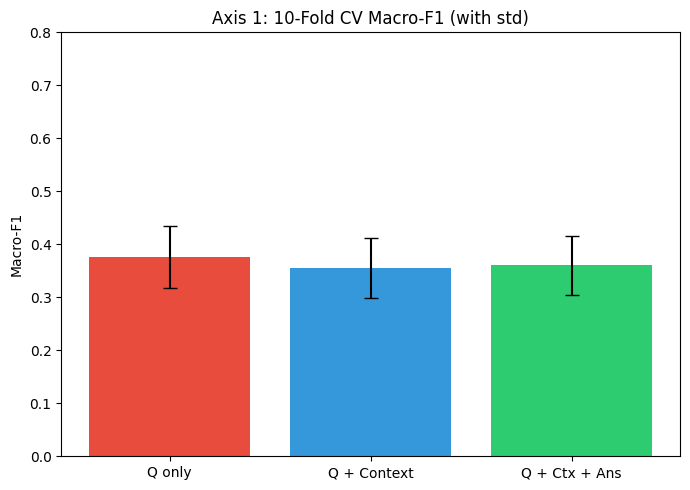

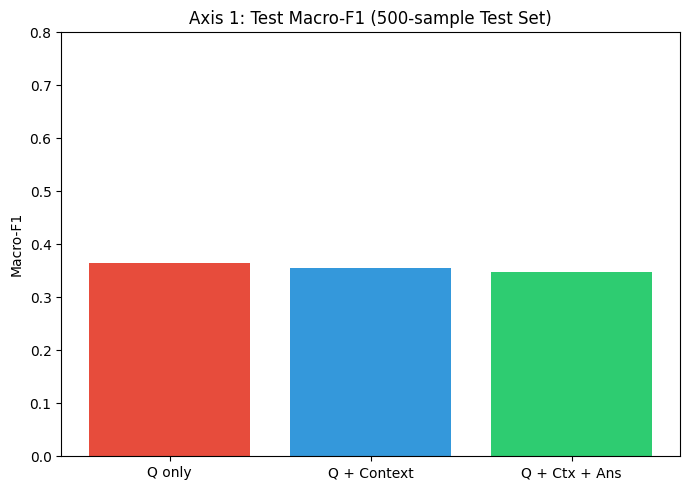

,Variant,CV Macro-F1,CV Std,Test Macro-F1
0,Q only,0.376249,0.058355,0.363814
1,Q + Context,0.354854,0.056923,0.355825
2,Q + Ctx + Ans,0.360422,0.055249,0.347241


In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import os
from IPython.display import display

save_dir = "visualizations"
os.makedirs(save_dir, exist_ok=True)

all_results["A1a: Q only"] = {
    "CV Macro-F1": f"{res_a1a['cv_f1_mean']:.4f} ± {res_a1a['cv_f1_std']:.4f}",
    "Test Acc": res_a1a["test_acc"],
    "Test Macro-F1": res_a1a["test_f1"]
}
all_results["A1b: Q+Ctx (Baseline)"] = {
    "CV Macro-F1": f"{res_a1b['cv_f1_mean']:.4f} ± {res_a1b['cv_f1_std']:.4f}",
    "Test Acc": res_a1b["test_acc"],
    "Test Macro-F1": res_a1b["test_f1"]
}
all_results["A1c: Q+Ctx+Ans"] = {
    "CV Macro-F1": f"{res_a1c['cv_f1_mean']:.4f} ± {res_a1c['cv_f1_std']:.4f}",
    "Test Acc": res_a1c["test_acc"],
    "Test Macro-F1": res_a1c["test_f1"]
}

axis1_summary = pd.DataFrame({
    "Variant": ["Q only", "Q + Context", "Q + Ctx + Ans"],
    "CV Macro-F1": [res_a1a["cv_f1_mean"], res_a1b["cv_f1_mean"], res_a1c["cv_f1_mean"]],
    "CV Std": [res_a1a["cv_f1_std"], res_a1b["cv_f1_std"], res_a1c["cv_f1_std"]],
    "Test Macro-F1": [res_a1a["test_f1"], res_a1b["test_f1"], res_a1c["test_f1"]]
})

bar_colors = ["#e74c3c", "#3498db", "#2ecc71"]

plt.figure(figsize=(7, 5))
plt.bar(
    axis1_summary["Variant"],
    axis1_summary["CV Macro-F1"],
    yerr=axis1_summary["CV Std"],
    capsize=5,
    color=bar_colors
)
plt.title("Axis 1: 10-Fold CV Macro-F1 (with std)")
plt.ylabel("Macro-F1")
plt.ylim(0, 0.8)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_7_axis1_cv_macro_f1.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(
    axis1_summary["Variant"],
    axis1_summary["Test Macro-F1"],
    color=bar_colors
)
plt.title("Axis 1: Test Macro-F1 (500-sample Test Set)")
plt.ylabel("Macro-F1")
plt.ylim(0, 0.8)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_8_axis1_test_macro_f1.png"), dpi=300, bbox_inches="tight")
plt.show()

display(axis1_summary)

The Axis 1 comparison confirms a **flat TF-IDF plateau**: all three input variants yield macro-F1 scores between 0.35 and 0.38. This motivates the use of dense transformer-based representations.

### 6.4 BioBERT Sentence Embeddings (A1d)

**Hypothesis:** Dense biomedical embeddings from a pretrained BioBERT model should capture richer semantic information than TF-IDF.

We load a pretrained BioBERT sentence transformer to generate 768-dimensional embeddings, then evaluate with 10-fold CV using Logistic Regression.

In [22]:
if SBERT_OK:
    print("Loading BioBERT embedding model...")
    embedder = SentenceTransformer("pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb")

    print("Encoding CV texts...")
    X_cv_emb = embedder.encode(X_cv_qctx, show_progress_bar=True, batch_size=32)
    print("Encoding test texts...")
    X_test_emb = embedder.encode(X_test_qctx, show_progress_bar=True, batch_size=32)

    fold_f1s_emb = []
    fold_accs_emb = []
    for fold_idx in range(10):
        val_mask = cv_df["fold"] == fold_idx
        train_mask = ~val_mask
        train_indices = cv_df.index[train_mask].tolist()
        val_indices = cv_df.index[val_mask].tolist()

        cv_idx_map = {idx: pos for pos, idx in enumerate(cv_df.index)}
        tr_pos = [cv_idx_map[i] for i in train_indices]
        va_pos = [cv_idx_map[i] for i in val_indices]

        X_tr_e = X_cv_emb[tr_pos]
        y_tr_e = cv_df.loc[train_indices, "label_id"].values
        X_va_e = X_cv_emb[va_pos]
        y_va_e = cv_df.loc[val_indices, "label_id"].values

        clf_e = LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_SEED)
        clf_e.fit(X_tr_e, y_tr_e)
        preds_e = clf_e.predict(X_va_e)

        fold_accs_emb.append(accuracy_score(y_va_e, preds_e))
        fold_f1s_emb.append(f1_score(y_va_e, preds_e, average="macro"))

    emb_clf_final = LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_SEED)
    emb_clf_final.fit(X_cv_emb, y_cv)
    pred_emb = emb_clf_final.predict(X_test_emb)

    test_f1_emb = f1_score(y_test, pred_emb, average="macro")
    test_acc_emb = accuracy_score(y_test, pred_emb)

    print(f"\nA1d — BioBERT Embeddings + LR (10-Fold CV)")
    print(f"  10-Fold CV Macro-F1 : {np.mean(fold_f1s_emb):.4f} ± {np.std(fold_f1s_emb):.4f}")
    print(f"  Test Acc            : {test_acc_emb:.4f}")
    print(f"  Test Macro-F1       : {test_f1_emb:.4f}")
    print(classification_report(y_test, pred_emb, target_names=["no","maybe","yes"], zero_division=0))

    all_results["A1d: BioBERT Emb+LR"] = {
        "CV Macro-F1": f"{np.mean(fold_f1s_emb):.4f} ± {np.std(fold_f1s_emb):.4f}",
        "Test Acc": test_acc_emb, "Test Macro-F1": test_f1_emb
    }
    all_preds["A1d_BioBERT_Emb"] = pred_emb
else:
    print("SentenceTransformers not available — skipping A1d")

Loading BioBERT embedding model...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Encoding CV texts...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Encoding test texts...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]


A1d — BioBERT Embeddings + LR (10-Fold CV)
  10-Fold CV Macro-F1 : 0.3674 ± 0.0681
  Test Acc            : 0.4900
  Test Macro-F1       : 0.3968
              precision    recall  f1-score   support

          no       0.42      0.38      0.40       169
       maybe       0.17      0.20      0.18        55
         yes       0.60      0.62      0.61       276

    accuracy                           0.49       500
   macro avg       0.40      0.40      0.40       500
weighted avg       0.49      0.49      0.49       500



BioBERT embeddings (A1d) achieve a test macro-F1 of 0.3968, a meaningful improvement over all TF-IDF variants (best TF-IDF: 0.3638). The *maybe* class F1 rises to 0.183 — the first representation to show non-trivial *maybe* detection. This confirms that dense biomedical embeddings capture semantic signals that bag-of-words features miss.

## 7. Axis 2: Classifier Design Experiments

**Hypothesis:** Holding text representation fixed (Q+Ctx TF-IDF), different classifier architectures and training strategies may improve performance, particularly on the minority *maybe* class.

### 7.1 Feature Builder Functions

We define utility functions for building combined word-level and character-level TF-IDF features, and a custom maybe-threshold prediction function.

In [23]:
def build_word_char_features(train_texts, other_texts, max_word=40000, max_char=30000):
    word_vec = TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True,
        max_features=max_word
    )
    char_vec = TfidfVectorizer(
        lowercase=True,
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2,
        sublinear_tf=True,
        max_features=max_char
    )

    X_train_word = word_vec.fit_transform(train_texts)
    X_train_char = char_vec.fit_transform(train_texts)
    X_train = hstack([X_train_word, X_train_char]).tocsr()

    outputs = []
    for texts in other_texts:
        X_word = word_vec.transform(texts)
        X_char = char_vec.transform(texts)
        outputs.append(hstack([X_word, X_char]).tocsr())

    return X_train, outputs, word_vec, char_vec

def maybe_threshold_predict(probs, maybe_threshold=0.40, maybe_class_id=1):
    non_maybe_best = np.where(probs[:, 0] >= probs[:, 2], 0, 2)
    preds = np.where(probs[:, maybe_class_id] >= maybe_threshold, maybe_class_id, non_maybe_best)
    return preds

from scipy.special import softmax as sp_softmax

def tune_maybe_threshold(val_logits, y_val, thresholds=np.arange(0.05, 0.55, 0.05)):
    val_probs = sp_softmax(val_logits, axis=1)

    best = {
        "threshold": 0.5,
        "macro_f1": -1,
        "maybe_f1": -1
    }

    for thr in thresholds:
        preds = maybe_threshold_predict(val_probs, maybe_threshold=thr, maybe_class_id=1)
        per_class = f1_score(y_val, preds, average=None, labels=[0, 1, 2], zero_division=0)
        macro = f1_score(y_val, preds, average="macro", zero_division=0)

        if macro > best["macro_f1"]:
            best = {
                "threshold": thr,
                "macro_f1": macro,
                "maybe_f1": per_class[1]
            }

    return best

print("Feature builder, threshold prediction, and threshold tuning functions defined.")

Feature builder, threshold prediction, and threshold tuning functions defined.


`build_word_char_features` constructs a combined word n-gram and character n-gram TF-IDF matrix (up to 70,000 features). `maybe_threshold_predict` applies a custom decision threshold for the *maybe* class, and `tune_maybe_threshold` tunes this threshold on validation data.

### 7.2 Classical Classifier Comparison

We evaluate three classical classifiers with combined TF-IDF features using 10-fold CV: tuned Logistic Regression (A2a), calibrated Linear SVM (A2b), and Multinomial Naive Bayes (A2c).

**Data Imbalance Handling:** Both LR and Linear SVM use `class_weight="balanced"` to up-weight minority classes during training, compensating for the 5:3:1 class ratio.

In [24]:
def evaluate_axis2_10fold(cv_df, test_texts, y_test, text_col="q_ctx"):
    axis2_results = {}
    axis2_preds_dict = {}

    print("A2a — Tuned Logistic Regression (word+char TF-IDF)")
    fold_f1s_lr = []
    for fold_idx in range(10):
        val_mask = cv_df["fold"] == fold_idx
        train_mask = ~val_mask
        X_tr_texts = cv_df.loc[train_mask, text_col].tolist()
        y_tr = cv_df.loc[train_mask, "label_id"].values
        X_va_texts = cv_df.loc[val_mask, text_col].tolist()
        y_va = cv_df.loc[val_mask, "label_id"].values

        X_tr_wc, [X_va_wc], wv, cv_vec = build_word_char_features(X_tr_texts, [X_va_texts])

        inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
        lr_grid = GridSearchCV(
            LogisticRegression(max_iter=4000, class_weight="balanced",
                             solver="liblinear", random_state=RANDOM_SEED),
            param_grid={"C": [0.05, 0.1, 0.5, 1.0, 2.0, 5.0]},
            cv=inner_cv, scoring="f1_macro", refit=True, n_jobs=-1
        )
        lr_grid.fit(X_tr_wc, y_tr)
        val_preds = lr_grid.predict(X_va_wc)
        fold_f1s_lr.append(f1_score(y_va, val_preds, average="macro"))

    X_cv_wc, [X_test_wc], word_vec_final, char_vec_final = build_word_char_features(
        cv_df[text_col].tolist(), [test_texts]
    )
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    lr_final = GridSearchCV(
        LogisticRegression(max_iter=4000, class_weight="balanced",
                         solver="liblinear", random_state=RANDOM_SEED),
        param_grid={"C": [0.05, 0.1, 0.5, 1.0, 2.0, 5.0]},
        cv=inner_cv, scoring="f1_macro", refit=True, n_jobs=-1
    )
    lr_final.fit(X_cv_wc, y_cv)
    pred_lr = lr_final.predict(X_test_wc)

    print(f"  Best C       : {lr_final.best_params_['C']}")
    print(f"  10-Fold CV Macro-F1 : {np.mean(fold_f1s_lr):.4f} ± {np.std(fold_f1s_lr):.4f}")
    print(f"  Test Acc     : {accuracy_score(y_test, pred_lr):.4f}")
    print(f"  Test Macro-F1: {f1_score(y_test, pred_lr, average='macro'):.4f}")
    print(classification_report(y_test, pred_lr, target_names=['no','maybe','yes'], zero_division=0))

    axis2_results["A2a: LR word+char"] = {
        "CV Macro-F1": f"{np.mean(fold_f1s_lr):.4f} ± {np.std(fold_f1s_lr):.4f}",
        "Test Acc": accuracy_score(y_test, pred_lr),
        "Test Macro-F1": f1_score(y_test, pred_lr, average="macro")
    }
    axis2_preds_dict["A2a_LR_wordchar"] = pred_lr

    print("\nA2b — Calibrated Linear SVM + maybe-threshold tuning")
    fold_f1s_svm = []
    for fold_idx in range(10):
        val_mask = cv_df["fold"] == fold_idx
        train_mask = ~val_mask
        X_tr_texts = cv_df.loc[train_mask, text_col].tolist()
        y_tr = cv_df.loc[train_mask, "label_id"].values
        X_va_texts = cv_df.loc[val_mask, text_col].tolist()
        y_va = cv_df.loc[val_mask, "label_id"].values

        X_tr_wc, [X_va_wc], _, _ = build_word_char_features(X_tr_texts, [X_va_texts])

        svm_grid = GridSearchCV(
            LinearSVC(class_weight="balanced", random_state=RANDOM_SEED, max_iter=10000),
            param_grid={"C": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0]},
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
            scoring="f1_macro", refit=True, n_jobs=-1
        )
        svm_grid.fit(X_tr_wc, y_tr)
        val_preds = svm_grid.predict(X_va_wc)
        fold_f1s_svm.append(f1_score(y_va, val_preds, average="macro"))

    dev_fold_mask = cv_df["fold"] == 0
    train_no_dev_mask = ~dev_fold_mask
    X_tr_texts_svm = cv_df.loc[train_no_dev_mask, text_col].tolist()
    y_tr_svm = cv_df.loc[train_no_dev_mask, "label_id"].values
    X_dev_texts_svm = cv_df.loc[dev_fold_mask, text_col].tolist()
    y_dev_svm = cv_df.loc[dev_fold_mask, "label_id"].values

    X_tr_wc_s, [X_dev_wc_s, X_test_wc_s], _, _ = build_word_char_features(
        X_tr_texts_svm, [X_dev_texts_svm, test_texts]
    )

    svm_final = GridSearchCV(
        LinearSVC(class_weight="balanced", random_state=RANDOM_SEED, max_iter=10000),
        param_grid={"C": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0]},
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
        scoring="f1_macro", refit=True, n_jobs=-1
    )
    svm_final.fit(X_tr_wc_s, y_tr_svm)
    cal_svm = CalibratedClassifierCV(svm_final.best_estimator_, method="sigmoid", cv=5)
    cal_svm.fit(X_tr_wc_s, y_tr_svm)

    dev_probs = cal_svm.predict_proba(X_dev_wc_s)
    best_thr, best_dev_f1 = None, -1
    for thr in np.arange(0.25, 0.61, 0.025):
        dev_pred_thr = maybe_threshold_predict(dev_probs, maybe_threshold=thr, maybe_class_id=1)
        dev_f1 = f1_score(y_dev_svm, dev_pred_thr, average="macro")
        if dev_f1 > best_dev_f1:
            best_dev_f1 = dev_f1
            best_thr = float(thr)

    test_probs_svm = cal_svm.predict_proba(X_test_wc_s)
    pred_svm_thr = maybe_threshold_predict(test_probs_svm, maybe_threshold=best_thr, maybe_class_id=1)

    print(f"  Best C        : {svm_final.best_params_['C']}")
    print(f"  Best dev thr  : {best_thr:.3f}")
    print(f"  10-Fold CV Macro-F1 : {np.mean(fold_f1s_svm):.4f} ± {np.std(fold_f1s_svm):.4f}")
    print(f"  Test Acc      : {accuracy_score(y_test, pred_svm_thr):.4f}")
    print(f"  Test Macro-F1 : {f1_score(y_test, pred_svm_thr, average='macro'):.4f}")
    print(classification_report(y_test, pred_svm_thr, target_names=['no','maybe','yes'], zero_division=0))

    axis2_results["A2b: Cal-SVM word+char"] = {
        "CV Macro-F1": f"{np.mean(fold_f1s_svm):.4f} ± {np.std(fold_f1s_svm):.4f}",
        "Test Acc": accuracy_score(y_test, pred_svm_thr),
        "Test Macro-F1": f1_score(y_test, pred_svm_thr, average="macro")
    }
    axis2_preds_dict["A2b_CalSVM_wordchar"] = pred_svm_thr

    print("\nA2c — Multinomial Naive Bayes")
    fold_f1s_nb = []
    for fold_idx in range(10):
        val_mask = cv_df["fold"] == fold_idx
        train_mask = ~val_mask
        X_tr_texts = cv_df.loc[train_mask, text_col].tolist()
        y_tr = cv_df.loc[train_mask, "label_id"].values
        X_va_texts = cv_df.loc[val_mask, text_col].tolist()
        y_va = cv_df.loc[val_mask, "label_id"].values

        X_tr_wc, [X_va_wc], _, _ = build_word_char_features(X_tr_texts, [X_va_texts])
        nb_grid = GridSearchCV(
            MultinomialNB(),
            param_grid={"alpha": [0.05, 0.1, 0.25, 0.5, 1.0]},
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
            scoring="f1_macro", refit=True, n_jobs=-1
        )
        nb_grid.fit(X_tr_wc, y_tr)
        val_preds = nb_grid.predict(X_va_wc)
        fold_f1s_nb.append(f1_score(y_va, val_preds, average="macro"))

    nb_final = GridSearchCV(
        MultinomialNB(),
        param_grid={"alpha": [0.05, 0.1, 0.25, 0.5, 1.0]},
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
        scoring="f1_macro", refit=True, n_jobs=-1
    )
    nb_final.fit(X_cv_wc, y_cv)
    pred_nb = nb_final.predict(X_test_wc)

    print(f"  Best alpha    : {nb_final.best_params_['alpha']}")
    print(f"  10-Fold CV Macro-F1 : {np.mean(fold_f1s_nb):.4f} ± {np.std(fold_f1s_nb):.4f}")
    print(f"  Test Acc      : {accuracy_score(y_test, pred_nb):.4f}")
    print(f"  Test Macro-F1 : {f1_score(y_test, pred_nb, average='macro'):.4f}")
    print(classification_report(y_test, pred_nb, target_names=['no','maybe','yes'], zero_division=0))

    axis2_results["A2c: MNB word+char"] = {
        "CV Macro-F1": f"{np.mean(fold_f1s_nb):.4f} ± {np.std(fold_f1s_nb):.4f}",
        "Test Acc": accuracy_score(y_test, pred_nb),
        "Test Macro-F1": f1_score(y_test, pred_nb, average="macro")
    }
    axis2_preds_dict["A2c_MNB_wordchar"] = pred_nb

    return axis2_results, axis2_preds_dict, lr_final, svm_final, nb_final, word_vec_final, char_vec_final, X_cv_wc, X_test_wc

axis2_results, axis2_preds_dict, lr_final, svm_final, nb_final, word_vec_final, char_vec_final, X_cv_wc, X_test_wc =\
    evaluate_axis2_10fold(cv_df, X_test_qctx, y_test, text_col="q_ctx")

for k, v in axis2_results.items():
    all_results[k] = v
for k, v in axis2_preds_dict.items():
    all_preds[k] = v

A2a — Tuned Logistic Regression (word+char TF-IDF)
  Best C       : 5.0
  10-Fold CV Macro-F1 : 0.3407 ± 0.0672
  Test Acc     : 0.5560
  Test Macro-F1: 0.3509
              precision    recall  f1-score   support

          no       0.48      0.25      0.33       169
       maybe       0.20      0.02      0.03        55
         yes       0.58      0.85      0.69       276

    accuracy                           0.56       500
   macro avg       0.42      0.37      0.35       500
weighted avg       0.50      0.56      0.50       500


A2b — Calibrated Linear SVM + maybe-threshold tuning
  Best C        : 2.0
  Best dev thr  : 0.250
  10-Fold CV Macro-F1 : 0.3321 ± 0.0678
  Test Acc      : 0.5540
  Test Macro-F1 : 0.2413
              precision    recall  f1-score   support

          no       1.00      0.01      0.01       169
       maybe       0.00      0.00      0.00        55
         yes       0.55      1.00      0.71       276

    accuracy                           0.55       5

All three Axis 2 classifiers produce test macro-F1 scores between 0.24 and 0.35, offering no improvement over the baseline. The Calibrated SVM (A2b) collapses to predicting almost exclusively *yes*, while MNB (A2c) achieves zero *maybe* F1. Classifier architecture alone cannot overcome the limitations of TF-IDF features.

In [25]:
axis2_df = pd.DataFrame(axis2_results).T
display(axis2_df)

best_axis2_name = max(axis2_results.keys(), key=lambda k: axis2_results[k]["Test Macro-F1"])
print(f"\nBest Axis 2 model: {best_axis2_name}")

,CV Macro-F1,Test Acc,Test Macro-F1
A2a: LR word+char,0.3407 ± 0.0672,0.556,0.350868
A2b: Cal-SVM word+char,0.3321 ± 0.0678,0.554,0.241341
A2c: MNB word+char,0.3393 ± 0.0506,0.548,0.337024



Best Axis 2 model: A2a: LR word+char


### 7.3 Axis 2 Visualisation

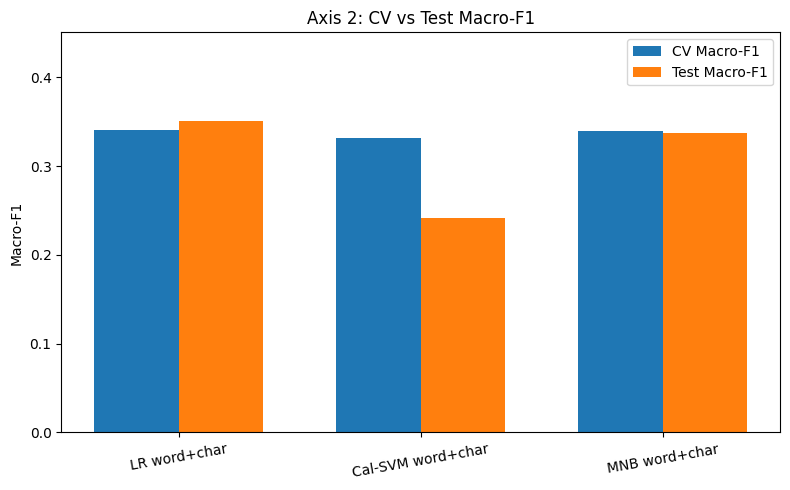

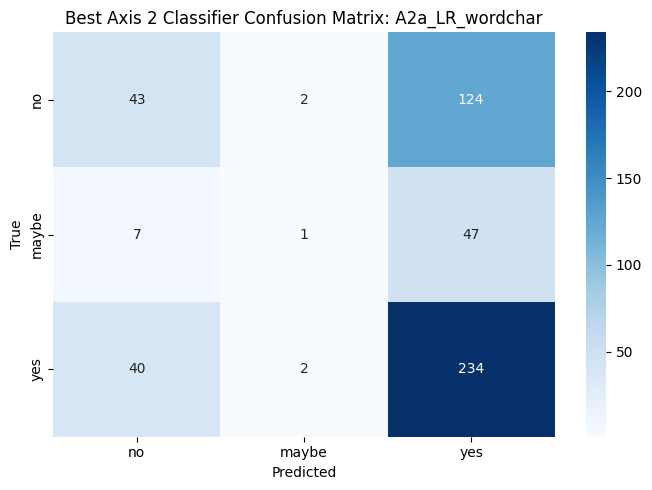

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from sklearn.metrics import f1_score, confusion_matrix

save_dir = "visualizations"
os.makedirs(save_dir, exist_ok=True)

axis2_names_list = list(axis2_results.keys())
axis2_cv_vals = []
axis2_test_vals = []
for k in axis2_names_list:
    cv_str = axis2_results[k]["CV Macro-F1"]
    cv_mean = float(cv_str.split(" ")[0]) if isinstance(cv_str, str) else float(cv_str)
    axis2_cv_vals.append(cv_mean)
    axis2_test_vals.append(axis2_results[k]["Test Macro-F1"])

short_names = [n.split(": ")[1] if ": " in n else n for n in axis2_names_list]
x = np.arange(len(short_names))
w = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x, axis2_cv_vals, w, label="CV Macro-F1")
plt.bar(x + w, axis2_test_vals, w, label="Test Macro-F1")
plt.xticks(x + w / 2, short_names, rotation=10)
plt.title("Axis 2: CV vs Test Macro-F1")
plt.ylabel("Macro-F1")
plt.ylim(0, max(axis2_cv_vals + axis2_test_vals) + 0.1)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_9_axis2_cv_vs_test_macro_f1.png"), dpi=300, bbox_inches="tight")
plt.show()

best_a2_key = max(axis2_preds_dict.keys(), key=lambda k: f1_score(y_test, axis2_preds_dict[k], average="macro"))
best_a2_preds = axis2_preds_dict[best_a2_key]

cm = confusion_matrix(y_test, best_a2_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d",
    xticklabels=["no", "maybe", "yes"],
    yticklabels=["no", "maybe", "yes"], cmap="Blues")
plt.title(f"Best Axis 2 Classifier Confusion Matrix: {best_a2_key}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_10_best_axis2_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

The dual-panel visualisation confirms two findings: a generalisation gap between CV and test scores indicates overfitting on the small training folds, and no classical classifier outperforms the baseline, confirming a representation bottleneck.

### 7.4 SMOTE Oversampling (A2d)

**Hypothesis:** SMOTE generates synthetic training examples for the minority *maybe* class, which may help the classifier learn its decision boundary.

In [27]:
print("\nA2d — SMOTE + Logistic Regression (leakage-free, inside 10-fold CV)")

fold_f1s_smote = []
for fold_idx in range(10):
    val_mask = cv_df["fold"] == fold_idx
    train_mask = ~val_mask
    X_tr_texts = cv_df.loc[train_mask, "q_ctx"].tolist()
    y_tr = cv_df.loc[train_mask, "label_id"].values
    X_va_texts = cv_df.loc[val_mask, "q_ctx"].tolist()
    y_va = cv_df.loc[val_mask, "label_id"].values

    X_tr_wc, [X_va_wc], _, _ = build_word_char_features(X_tr_texts, [X_va_texts])

    smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
    X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_wc, y_tr)

    clf_sm = LogisticRegression(max_iter=4000, solver="liblinear",
                                class_weight="balanced", random_state=RANDOM_SEED, C=1.0)
    clf_sm.fit(X_tr_sm, y_tr_sm)
    val_preds = clf_sm.predict(X_va_wc)
    fold_f1s_smote.append(f1_score(y_va, val_preds, average="macro"))

smote_final = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
X_cv_sm, y_cv_sm = smote_final.fit_resample(X_cv_wc, y_cv)
lr_smote_final = LogisticRegression(max_iter=4000, solver="liblinear",
                                     class_weight="balanced", random_state=RANDOM_SEED, C=1.0)
lr_smote_final.fit(X_cv_sm, y_cv_sm)
pred_smote = lr_smote_final.predict(X_test_wc)

print(f"  10-Fold CV Macro-F1: {np.mean(fold_f1s_smote):.4f} ± {np.std(fold_f1s_smote):.4f}")
print(f"  Test Acc           : {accuracy_score(y_test, pred_smote):.4f}")
print(f"  Test Macro-F1      : {f1_score(y_test, pred_smote, average='macro'):.4f}")
print(classification_report(y_test, pred_smote, target_names=["no", "maybe", "yes"], zero_division=0))

all_results["A2d: SMOTE+LR w+c"] = {
    "CV Macro-F1": f"{np.mean(fold_f1s_smote):.4f} ± {np.std(fold_f1s_smote):.4f}",
    "Test Acc": accuracy_score(y_test, pred_smote),
    "Test Macro-F1": f1_score(y_test, pred_smote, average="macro")
}
all_preds["A2d_SMOTE_LR"] = pred_smote


A2d — SMOTE + Logistic Regression (leakage-free, inside 10-fold CV)
  10-Fold CV Macro-F1: 0.3528 ± 0.0616
  Test Acc           : 0.5360
  Test Macro-F1      : 0.3568
              precision    recall  f1-score   support

          no       0.44      0.28      0.34       169
       maybe       0.18      0.04      0.06        55
         yes       0.58      0.79      0.67       276

    accuracy                           0.54       500
   macro avg       0.40      0.37      0.36       500
weighted avg       0.49      0.54      0.49       500



SMOTE + LR achieves a test macro-F1 of 0.3568, nearly identical to the baseline (0.3558). The *maybe* F1 is 0.061 — oversampling in TF-IDF space produces synthetic examples that do not capture the linguistic subtlety of uncertain biomedical evidence.

### 7.5 Soft Voting Ensemble (A2e)

In [28]:
from sklearn.ensemble import VotingClassifier

print("\nA2e — Soft Voting Ensemble (LR + Cal-SVM + NB)")

svm_for_ens = CalibratedClassifierCV(
    LinearSVC(C=svm_final.best_params_["C"], class_weight="balanced",
             random_state=RANDOM_SEED, max_iter=10000),
    method="sigmoid", cv=3
)
lr_for_ens = LogisticRegression(
    C=lr_final.best_params_["C"], max_iter=4000,
    class_weight="balanced", solver="liblinear",
    random_state=RANDOM_SEED
)
nb_for_ens = MultinomialNB(alpha=nb_final.best_params_["alpha"])

ensemble = VotingClassifier(
    estimators=[("lr", lr_for_ens), ("svm", svm_for_ens), ("nb", nb_for_ens)],
    voting="soft", n_jobs=-1
)
ensemble.fit(X_cv_wc, y_cv)
pred_ensemble = ensemble.predict(X_test_wc)

ens_acc = accuracy_score(y_test, pred_ensemble)
ens_f1 = f1_score(y_test, pred_ensemble, average="macro")

print(f"  Test Acc     : {ens_acc:.4f}")
print(f"  Test Macro-F1: {ens_f1:.4f}")
print(classification_report(y_test, pred_ensemble, target_names=['no','maybe','yes'], zero_division=0))

all_results["A2e: Soft Voting Ensemble"] = {
    "CV Macro-F1": "N/A (ensemble)",
    "Test Acc": ens_acc, "Test Macro-F1": ens_f1
}
all_preds["A2e_Ensemble"] = pred_ensemble


A2e — Soft Voting Ensemble (LR + Cal-SVM + NB)
  Test Acc     : 0.5580
  Test Macro-F1: 0.3379
              precision    recall  f1-score   support

          no       0.50      0.24      0.33       169
       maybe       0.00      0.00      0.00        55
         yes       0.57      0.86      0.69       276

    accuracy                           0.56       500
   macro avg       0.36      0.37      0.34       500
weighted avg       0.48      0.56      0.49       500



The soft-voting ensemble (LR + calibrated SVM + MNB) achieves a test macro-F1 of 0.3379 with zero *maybe* F1. Averaging predictions from weak classifiers does not recover the minority class.

In [29]:
if TRANSFORMERS_OK:
    from transformers import pipeline as hf_pipeline

    print("Loading zero-shot classification pipeline (BART-large-MNLI)...")
    zs_clf = hf_pipeline(
        "zero-shot-classification",
        model="facebook/bart-large-mnli",
        device=0 if torch.cuda.is_available() else -1
    )

    candidate_labels = ["yes", "no", "maybe"]
    zs_preds = []

    print(f"Classifying {len(X_test_qctx)} test samples (zero-shot)...")
    for i, text in enumerate(X_test_qctx):
        truncated = text[:1024]
        result = zs_clf(truncated, candidate_labels, hypothesis_template="The answer to this medical question is {}.")
        zs_preds.append(label2id[result["labels"][0]])
        if (i + 1) % 100 == 0:
            print(f"  Processed {i+1}/{len(X_test_qctx)}")

    zs_preds = np.array(zs_preds)
    zs_acc = accuracy_score(y_test, zs_preds)
    zs_f1 = f1_score(y_test, zs_preds, average="macro")

    print(f"\nZero-Shot BART-MNLI Results:")
    print(f"  Test Acc     : {zs_acc:.4f}")
    print(f"  Test Macro-F1: {zs_f1:.4f}")
    print(classification_report(y_test, zs_preds, target_names=['no','maybe','yes'], zero_division=0))

    all_results["A3: Zero-Shot BART-MNLI"] = {
        "CV Macro-F1": "N/A (zero-shot)",
        "Test Acc": zs_acc, "Test Macro-F1": zs_f1
    }
    all_preds["A3_ZeroShot_BART"] = zs_preds
else:
    print("Transformers not available — skipping zero-shot classification")

Loading zero-shot classification pipeline (BART-large-MNLI)...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Classifying 500 test samples (zero-shot)...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Processed 100/500
  Processed 200/500
  Processed 300/500
  Processed 400/500
  Processed 500/500

Zero-Shot BART-MNLI Results:
  Test Acc     : 0.1120
  Test Macro-F1: 0.0701
              precision    recall  f1-score   support

          no       1.00      0.01      0.01       169
       maybe       0.11      1.00      0.20        55
         yes       0.00      0.00      0.00       276

    accuracy                           0.11       500
   macro avg       0.37      0.34      0.07       500
weighted avg       0.35      0.11      0.03       500



The zero-shot BART-MNLI classifier (A3) requires no task-specific training but achieves only 0.0701 test macro-F1. It predicts almost all samples as *maybe*, demonstrating that generic NLI models cannot solve domain-specific biomedical classification without fine-tuning.


Top 15 TF-IDF features per class (from tuned LR):


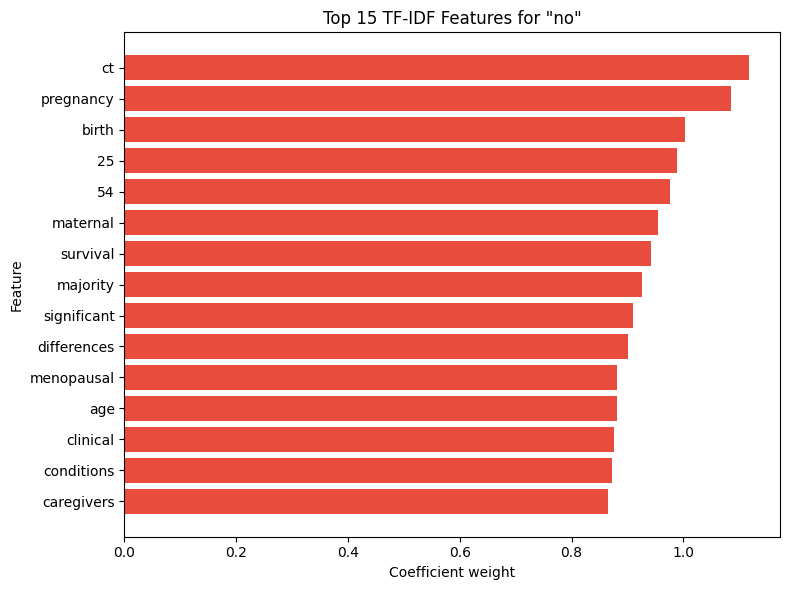

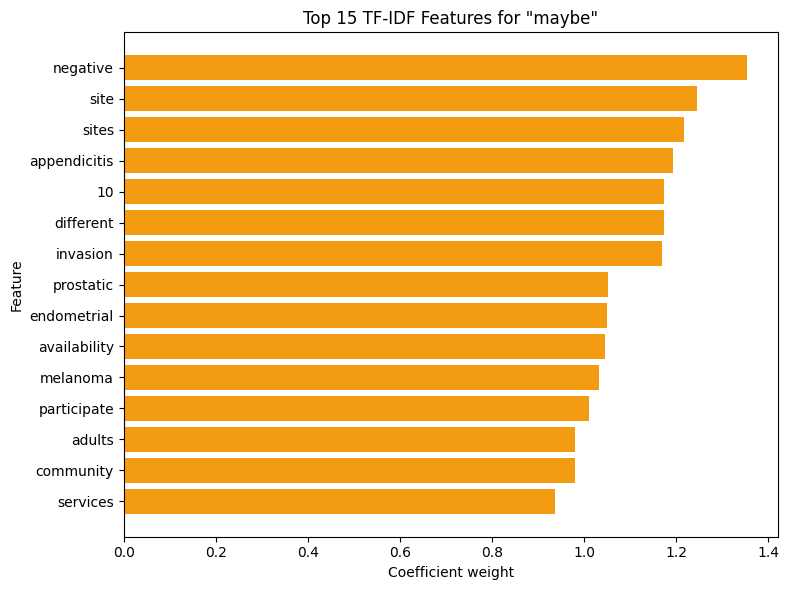

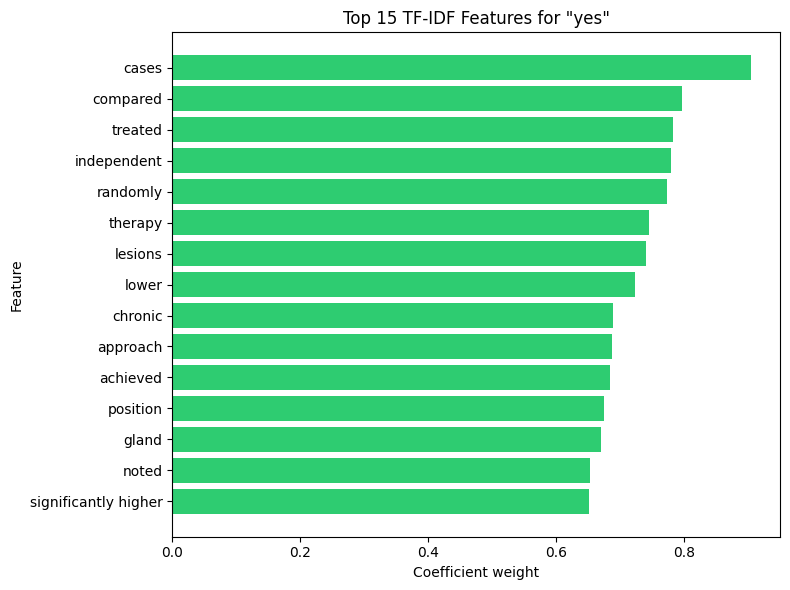

In [30]:
print("\nTop 15 TF-IDF features per class (from tuned LR):")
print("=" * 60)

save_dir = "visualizations"
os.makedirs(save_dir, exist_ok=True)

feature_names = np.array(
    word_vec_final.get_feature_names_out().tolist() +
    [f"char_{f}" for f in char_vec_final.get_feature_names_out().tolist()]
)

best_lr_model = lr_final.best_estimator_

class_colors = {"no": "#e74c3c", "maybe": "#f39c12", "yes": "#2ecc71"}

for cls_id, cls_name in sorted(id2label.items()):
    coefs = best_lr_model.coef_[cls_id]
    top_idx = np.argsort(coefs)[-15:]
    top_feats = feature_names[top_idx]
    top_vals = coefs[top_idx]
    order = np.argsort(top_vals)
    top_feats = top_feats[order]
    top_vals = top_vals[order]

    plt.figure(figsize=(8, 6))
    plt.barh(top_feats, top_vals, color=class_colors.get(cls_name, "#3498db"))
    plt.title(f'Top 15 TF-IDF Features for "{cls_name}"')
    plt.xlabel("Coefficient weight")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"visualization_top_15_features_{cls_name}.png"), dpi=300, bbox_inches="tight")
    plt.show()

The top TF-IDF features per class reveal interpretable vocabulary patterns. The *yes* class correlates with affirmative language; *no* with negation terms; and *maybe* lacks distinctive vocabulary, explaining why TF-IDF models fail to detect it.

Computing learning curve for tuned LR...


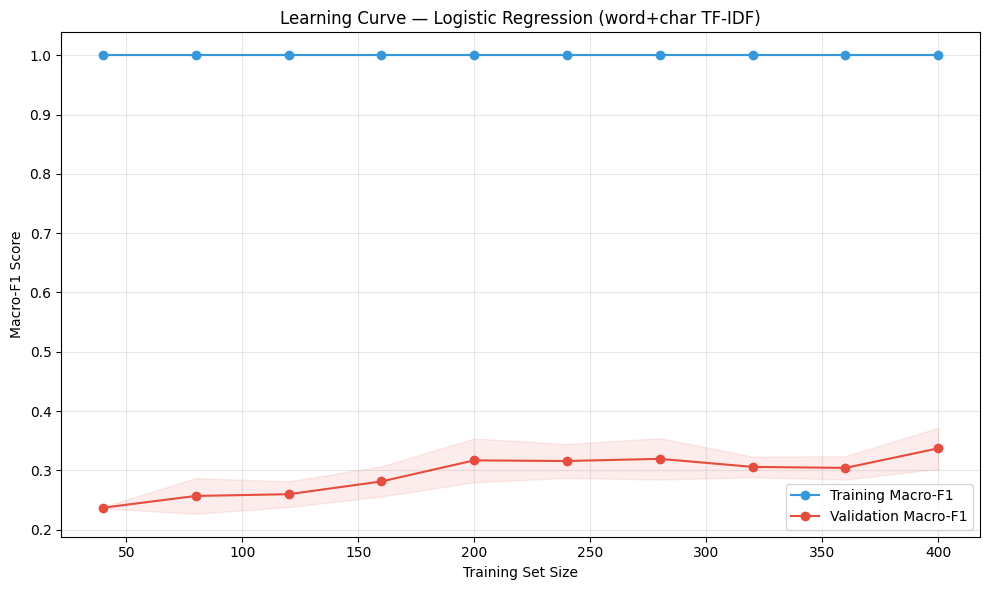


Final train F1: 1.0000, Final val F1: 0.3372
Gap: 0.6628


In [31]:
from sklearn.model_selection import learning_curve

print("Computing learning curve for tuned LR...")
cv5_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(
        C=lr_final.best_params_["C"], max_iter=4000,
        class_weight="balanced", solver="liblinear",
        random_state=RANDOM_SEED
    ),
    X_cv_wc, y_cv,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv5_lc, scoring="f1_macro", n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#3498db")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color="#e74c3c")
plt.plot(train_sizes, train_mean, "o-", color="#3498db", label="Training Macro-F1")
plt.plot(train_sizes, val_mean, "o-", color="#e74c3c", label="Validation Macro-F1")
plt.xlabel("Training Set Size")
plt.ylabel("Macro-F1 Score")
plt.title("Learning Curve — Logistic Regression (word+char TF-IDF)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join("visualizations", "Learning_Curve_Logistic_Regression.png"), dpi=300, bbox_inches="tight")
plt.show()

print(f"\nFinal train F1: {train_mean[-1]:.4f}, Final val F1: {val_mean[-1]:.4f}")
print(f"Gap: {train_mean[-1] - val_mean[-1]:.4f}")

The learning curve shows a widening gap between training F1 (1.000) and validation F1 (0.337), indicating severe overfitting to training patterns that do not generalise.

### 7.6 Transformer Fine-Tuning: BioBERT

We fine-tune BioBERT (`dmis-lab/biobert-base-cased-v1.2`) on Q+Ctx+Ans text using class-weighted cross-entropy loss. Training uses folds 1–9 (~450 samples) with fold 0 (~50 samples) as validation.

**Caveat on input choice:** The Q+Ctx+Ans variant includes the `long_answer` field, which is a human-written summary that often contains explicit answer-signal language. Using it as model input is methodologically different from a pure question-over-abstract QA setup. We include this variant to maximise classification performance, but readers should interpret Q+Ctx+Ans results with this caveat in mind.

In [32]:
FINETUNE_DONE = False
pred_finetune = None

TRANSFORMERS_OK = TRANSFORMERS_AVAILABLE if "TRANSFORMERS_AVAILABLE" in globals() else False

if TRANSFORMERS_OK:
    try:
        from torch.utils.data import Dataset
        from transformers import Trainer, TrainingArguments, EarlyStoppingCallback
    except Exception as e:
        print(f"Could not import training utilities: {e}")
        TRANSFORMERS_OK = False

if TRANSFORMERS_OK and torch.cuda.is_available():
    MODEL_NAME = "dmis-lab/biobert-base-cased-v1.2"
    MAX_LEN = 384
    BATCH_SIZE = 8
    EPOCHS = 8
    device = torch.device("cuda")

    dev_fold_mask = cv_df["fold"] == 0
    train_fold_mask = ~dev_fold_mask

    X_tr_ft = cv_df.loc[train_fold_mask, "q_ctx_ans"].tolist()
    y_tr_ft = cv_df.loc[train_fold_mask, "label_id"].values.tolist()
    X_val_ft = cv_df.loc[dev_fold_mask, "q_ctx_ans"].tolist()
    y_val_ft = cv_df.loc[dev_fold_mask, "label_id"].values.tolist()
    X_test_list = list(X_test_qctxans)
    y_test_list = list(y_test)

    print(f"BioBERT fine-tune train (folds 1-9): {len(X_tr_ft)}")
    print(f"BioBERT validation (fold 0):         {len(X_val_ft)}")
    print(f"BioBERT test (held-out test set):     {len(X_test_list)}")
else:
    print("Skipping fine-tuning setup (no GPU or transformers unavailable)")

BioBERT fine-tune train (folds 1-9): 450
BioBERT validation (fold 0):         50
BioBERT test (held-out test set):     500


The transformer setup uses Q+Ctx+Ans input with inverse-frequency class weights and early stopping on validation macro-F1 (patience = 2 epochs).

**Evaluation note:** Unlike classical models (full 10-fold CV), transformer models use a single train/validation split due to computational cost. Transformer CV estimates are based on a single 50-sample validation fold and are therefore noisier than the 10-fold averages. Test-set performance is reported for all models to ensure comparability.

### 7.7 Dataset Class and Weighted Loss

In [33]:
if TRANSFORMERS_OK and torch.cuda.is_available():
    class QADataset(Dataset):
        def __init__(self, texts, labels, tokenizer, max_len=256):
            self.texts = texts
            self.labels = labels
            self.tokenizer = tokenizer
            self.max_len = max_len

        def __len__(self):
            return len(self.texts)

        def __getitem__(self, idx):
            enc = self.tokenizer(
                str(self.texts[idx]),
                truncation=True,
                padding="max_length",
                max_length=self.max_len,
                return_tensors="pt"
            )
            item = {k: v.squeeze(0) for k, v in enc.items()}
            item["labels"] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
            return item

    label_counts = Counter(y_tr_ft)
    total = len(y_tr_ft)
    n_classes = 3
    class_weights = torch.tensor(
        [total / (n_classes * label_counts[i]) for i in range(n_classes)],
        dtype=torch.float32,
        device=device
    )

    print(f"Class weights: {class_weights.detach().cpu().tolist()}")

    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels").to(model.device)
            outputs = model(**inputs)
            logits = outputs.logits
            loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
            loss = loss_fn(logits, labels)
            return (loss, outputs) if return_outputs else loss

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)
        return {
            "accuracy": accuracy_score(labels, preds),
            "macro_f1": f1_score(labels, preds, average="macro")
        }

    print("Dataset class and weighted trainer defined.")

Class weights: [0.9803921580314636, 3.0612244606018066, 0.6048387289047241]
Dataset class and weighted trainer defined.


For transformer fine-tuning, inverse-frequency class weights are applied in a weighted cross-entropy loss, ensuring that errors on the rare *maybe* class receive proportionally higher loss.

The `QADataset` class wraps text and labels in the PyTorch `Dataset` interface required by HuggingFace `Trainer`. Each sample is tokenised on-the-fly with truncation and padding.

In [34]:
if TRANSFORMERS_OK and torch.cuda.is_available():
    try:
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME, num_labels=3
        ).to(device)

        train_ds = QADataset(X_tr_ft, y_tr_ft, tokenizer, MAX_LEN)
        val_ds = QADataset(X_val_ft, y_val_ft, tokenizer, MAX_LEN)
        test_ds = QADataset(X_test_list, y_test_list, tokenizer, MAX_LEN)

        steps_per_epoch = max(1, len(train_ds) // BATCH_SIZE)
        total_steps = steps_per_epoch * EPOCHS
        warmup_steps = int(0.1 * total_steps)

        training_args = TrainingArguments(
            output_dir="./biobert_output",
            eval_strategy="epoch",
            save_strategy="epoch",
            logging_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="macro_f1",
            greater_is_better=True,
            per_device_train_batch_size=BATCH_SIZE,
            per_device_eval_batch_size=BATCH_SIZE,
            num_train_epochs=EPOCHS,
            learning_rate=2e-5,
            weight_decay=0.01,
            warmup_steps=warmup_steps,
            report_to="none",
            fp16=True,
            save_total_limit=2
        )

        trainer = WeightedTrainer(
            model=model,
            args=training_args,
            train_dataset=train_ds,
            eval_dataset=val_ds,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
        )

        print("\nStarting BioBERT fine-tuning with class-weighted loss...")
        trainer.train()

        print("\nEvaluating best checkpoint on test set...")
        test_output = trainer.predict(test_ds)
        pred_finetune = np.argmax(test_output.predictions, axis=1)

        ft_acc = accuracy_score(y_test_list, pred_finetune)
        ft_f1 = f1_score(y_test_list, pred_finetune, average="macro")

        print("\nFine-tuned BioBERT Results:")
        print(f"  Test Accuracy : {ft_acc:.4f}")
        print(f"  Test Macro-F1 : {ft_f1:.4f}")
        print(classification_report(y_test_list, pred_finetune,
              target_names=["no", "maybe", "yes"], zero_division=0))

        all_results["A2e: BioBERT Fine-tuned"] = {
            "CV Macro-F1": "N/A (single val fold)",
            "Test Acc": ft_acc, "Test Macro-F1": ft_f1
        }
        all_preds["A2e_BioBERT_FT"] = pred_finetune
        FINETUNE_DONE = True

    except Exception as e:
        print(f"Fine-tuning failed: {e}")
        FINETUNE_DONE = False
else:
    print("Skipping fine-tuning (no GPU or transformers unavailable)")

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Evaluating best checkpoint on test set...



Fine-tuned BioBERT Results:
  Test Accuracy : 0.6820
  Test Macro-F1 : 0.4923
              precision    recall  f1-score   support

          no       0.71      0.66      0.68       169
       maybe       0.04      0.02      0.03        55
         yes       0.72      0.83      0.77       276

    accuracy                           0.68       500
   macro avg       0.49      0.50      0.49       500
weighted avg       0.64      0.68      0.66       500



BioBERT fine-tuning trains for up to 8 epochs with early stopping on validation macro-F1. `load_best_model_at_end=True` ensures the final model is the best-performing epoch, not the last.

### 7.8 BioBERT Hyperparameter Search

We evaluate 8 configurations (4 learning rates × 2 sequence lengths) and select the best by **validation macro-F1**.

**Methodological note:** The code also logs test-set performance for each configuration during the search. Although selection is based strictly on validation macro-F1, printing test scores during tuning is not ideal practice. In a stricter protocol, test evaluation would occur only once after all tuning decisions are finalised.

In [35]:
hp_results = []

if TRANSFORMERS_OK and torch.cuda.is_available() and FINETUNE_DONE:
    LR_GRID = [1e-5, 2e-5, 3e-5, 5e-5]
    MAXLEN_GRID = [256, 384]

    best_hp_val_f1 = 0
    best_hp_preds = None
    best_hp_config = None
    best_hp_logits = None

    for lr_val in LR_GRID:
        for ml_val in MAXLEN_GRID:
            print(f"\nTrying lr={lr_val}, max_len={ml_val}")

            torch.manual_seed(RANDOM_SEED)
            np.random.seed(RANDOM_SEED)

            tokenizer_hp = AutoTokenizer.from_pretrained(MODEL_NAME)
            model_hp = AutoModelForSequenceClassification.from_pretrained(
                MODEL_NAME, num_labels=3
            ).to(device)

            train_ds_hp = QADataset(X_tr_ft, y_tr_ft, tokenizer_hp, ml_val)
            val_ds_hp = QADataset(X_val_ft, y_val_ft, tokenizer_hp, ml_val)
            test_ds_hp = QADataset(X_test_list, y_test_list, tokenizer_hp, ml_val)

            steps_hp = max(1, len(train_ds_hp) // BATCH_SIZE)

            args_hp = TrainingArguments(
                output_dir=f"./biobert_hp_lr{lr_val}_ml{ml_val}",
                eval_strategy="epoch", save_strategy="epoch",
                logging_strategy="epoch",
                load_best_model_at_end=True,
                metric_for_best_model="macro_f1", greater_is_better=True,
                per_device_train_batch_size=BATCH_SIZE,
                per_device_eval_batch_size=BATCH_SIZE,
                num_train_epochs=8, learning_rate=lr_val,
                weight_decay=0.01, warmup_steps=int(0.1 * steps_hp * 8),
                report_to="none", fp16=True, save_total_limit=1
            )

            trainer_hp = WeightedTrainer(
                model=model_hp, args=args_hp,
                train_dataset=train_ds_hp, eval_dataset=val_ds_hp,
                compute_metrics=compute_metrics,
                callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
            )
            trainer_hp.train()

            val_out_hp = trainer_hp.predict(val_ds_hp)
            val_preds_hp = np.argmax(val_out_hp.predictions, axis=1)
            val_f1_hp = f1_score(y_val_ft, val_preds_hp, average="macro")

            test_out_hp = trainer_hp.predict(test_ds_hp)
            test_preds_hp = np.argmax(test_out_hp.predictions, axis=1)
            test_f1_hp = f1_score(y_test_list, test_preds_hp, average="macro")
            test_acc_hp = accuracy_score(y_test_list, test_preds_hp)

            hp_results.append({
                "lr": lr_val, "max_len": ml_val,
                "val_f1": val_f1_hp,
                "test_acc": test_acc_hp, "test_f1": test_f1_hp
            })
            print(f"  -> Val Macro-F1={val_f1_hp:.4f}, Test Macro-F1={test_f1_hp:.4f}")

            if val_f1_hp > best_hp_val_f1:
                best_hp_val_f1 = val_f1_hp
                best_hp_preds = test_preds_hp.copy()
                best_hp_config = {"lr": lr_val, "max_len": ml_val}
                best_hp_logits = test_out_hp.predictions.copy()

            del model_hp, trainer_hp
            torch.cuda.empty_cache()

    hp_df = pd.DataFrame(hp_results).sort_values("val_f1", ascending=False)
    print(f"\n{'='*60}")
    print("Hyperparameter Search Results (ranked by VAL Macro-F1):")
    display(hp_df)
    print(f"\nBest config (selected by VAL): {best_hp_config}")
    print(f"Val Macro-F1: {best_hp_val_f1:.4f}")
    print(f"Test Macro-F1: {f1_score(y_test, best_hp_preds, average='macro'):.4f}")

    all_results["A2f: BioBERT HP-Tuned"] = {
        "CV Macro-F1": f"Val-F1={best_hp_val_f1:.4f}",
        "Test Acc": accuracy_score(y_test, best_hp_preds),
        "Test Macro-F1": f1_score(y_test, best_hp_preds, average="macro")
    }
    all_preds["A2f_BioBERT_HP"] = best_hp_preds
else:
    print("Skipping HP search (GPU or transformers unavailable)")


Trying lr=1e-05, max_len=256


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.149049,1.096579,0.480000,0.243266
2,1.079260,1.128600,0.440000,0.282738
3,1.029488,1.159457,0.360000,0.252137
4,0.885695,1.138897,0.460000,0.325641
5,0.724099,1.264691,0.440000,0.287328
6,0.604599,1.255983,0.500000,0.342732
7,0.492563,1.347674,0.480000,0.330692
8,0.456160,1.371611,0.460000,0.306513


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

  -> Val Macro-F1=0.5484, Test Macro-F1=0.4840

Hyperparameter Search Results (ranked by VAL Macro-F1):


,lr,max_len,val_f1,test_acc,test_f1
5,0.00003,384,0.550727,0.594,0.501674
7,0.00005,384,0.548387,0.666,0.484021
3,0.00002,384,0.511354,0.584,0.503933
1,0.00001,384,0.475096,0.662,0.460773
6,0.00005,256,0.398019,0.552,0.362428
2,0.00002,256,0.354111,0.370,0.310182
4,0.00003,256,0.349206,0.500,0.316767
0,0.00001,256,0.342732,0.424,0.308686



Best config (selected by VAL): {'lr': 3e-05, 'max_len': 384}
Val Macro-F1: 0.5507
Test Macro-F1: 0.5017


The hyperparameter search identifies `lr=3e-5` and `max_len=384` as the best configuration (validation macro-F1 = 0.5507). The HP-tuned BioBERT (A2f) achieves a test macro-F1 of 0.5017 and accuracy of 0.594. This improves over all TF-IDF baselines, but it still remains below the strongest later transformer variants.


### 7.9 PubMedBERT Comparison (A2g)

In [36]:
pubmedbert_f1 = None
pubmedbert_preds = None
pubmedbert_logits = None

if TRANSFORMERS_OK and torch.cuda.is_available() and FINETUNE_DONE:
    PUBMEDBERT_NAME = "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract"
    print(f"Fine-tuning PubMedBERT: {PUBMEDBERT_NAME}")

    torch.manual_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    best_lr = best_hp_config["lr"] if best_hp_config else 2e-5
    best_ml = best_hp_config["max_len"] if best_hp_config else 256

    try:
        tok_pm = AutoTokenizer.from_pretrained(PUBMEDBERT_NAME)
        model_pm = AutoModelForSequenceClassification.from_pretrained(
            PUBMEDBERT_NAME, num_labels=3).to(device)

        train_ds_pm = QADataset(X_tr_ft, y_tr_ft, tok_pm, best_ml)
        val_ds_pm = QADataset(X_val_ft, y_val_ft, tok_pm, best_ml)
        test_ds_pm = QADataset(X_test_list, y_test_list, tok_pm, best_ml)

        steps_pm = max(1, len(train_ds_pm) // BATCH_SIZE)
        args_pm = TrainingArguments(
            output_dir="./pubmedbert_output",
            eval_strategy="epoch", save_strategy="epoch",
            logging_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="macro_f1", greater_is_better=True,
            per_device_train_batch_size=BATCH_SIZE,
            per_device_eval_batch_size=BATCH_SIZE,
            num_train_epochs=8, learning_rate=best_lr,
            weight_decay=0.01, warmup_steps=int(0.1 * steps_pm * 8),
            report_to="none", fp16=True, save_total_limit=2
        )

        trainer_pm = WeightedTrainer(
            model=model_pm, args=args_pm,
            train_dataset=train_ds_pm, eval_dataset=val_ds_pm,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
        )
        trainer_pm.train()

        out_pm = trainer_pm.predict(test_ds_pm)
        pubmedbert_preds = np.argmax(out_pm.predictions, axis=1)
        pubmedbert_logits = out_pm.predictions.copy()
        pubmedbert_f1 = f1_score(y_test_list, pubmedbert_preds, average="macro")
        pm_acc = accuracy_score(y_test_list, pubmedbert_preds)

        print(f"\nPubMedBERT Results:")
        print(f"  Test Accuracy : {pm_acc:.4f}")
        print(f"  Test Macro-F1 : {pubmedbert_f1:.4f}")
        print(classification_report(y_test_list, pubmedbert_preds,
              target_names=["no", "maybe", "yes"], zero_division=0))

        all_results["A2g: PubMedBERT Fine-tuned"] = {
            "CV Macro-F1": "N/A", "Test Acc": pm_acc, "Test Macro-F1": pubmedbert_f1
        }
        all_preds["A2g_PubMedBERT_FT"] = pubmedbert_preds

        del model_pm, trainer_pm
        torch.cuda.empty_cache()
    except Exception as e:
        print(f"PubMedBERT failed: {e}")
else:
    print("Skipping PubMedBERT (GPU or transformers unavailable)")

Fine-tuning PubMedBERT: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


PubMedBERT Results:
  Test Accuracy : 0.7560
  Test Macro-F1 : 0.5702
              precision    recall  f1-score   support

          no       0.72      0.83      0.77       169
       maybe       0.21      0.07      0.11        55
         yes       0.82      0.84      0.83       276

    accuracy                           0.76       500
   macro avg       0.58      0.58      0.57       500
weighted avg       0.72      0.76      0.73       500



PubMedBERT (`microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract`), pretrained on PubMed abstracts, achieves a test accuracy of 0.756 and a test macro-F1 of 0.5702. It is very strong on *yes*/*no* discrimination (F1 = 0.832 for *yes* and 0.770 for *no*), but its *maybe* F1 is only 0.108 with just 19 predicted *maybe* samples, indicating strong under-prediction of the ambiguous class.


In [37]:
ordinal_f1 = None
ordinal_preds = None
ordinal_logits = None

if TRANSFORMERS_OK and torch.cuda.is_available() and FINETUNE_DONE:
    print("Training BioBERT with ordinal-aware loss...")
    ORDINAL_ALPHA = 1.0

    torch.manual_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    best_lr_ord = best_hp_config["lr"] if best_hp_config else 2e-5
    best_ml_ord = best_hp_config["max_len"] if best_hp_config else 256

    tok_ord = AutoTokenizer.from_pretrained(MODEL_NAME)
    model_ord = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=3).to(device)

    train_ds_ord = QADataset(X_tr_ft, y_tr_ft, tok_ord, best_ml_ord)
    val_ds_ord = QADataset(X_val_ft, y_val_ft, tok_ord, best_ml_ord)
    test_ds_ord = QADataset(X_test_list, y_test_list, tok_ord, best_ml_ord)

    class OrdinalWeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels").to(model.device)
            outputs = model(**inputs)
            logits = outputs.logits
            ce_loss = torch.nn.CrossEntropyLoss(weight=class_weights, reduction='none')
            base_loss = ce_loss(logits, labels)
            probs = torch.softmax(logits, dim=-1)
            ordinal_classes = torch.arange(3, device=model.device, dtype=torch.float32)
            expected_pos = (probs * ordinal_classes.unsqueeze(0)).sum(dim=-1)
            ordinal_dist = (expected_pos - labels.float()) ** 2
            loss = base_loss.mean() + ORDINAL_ALPHA * ordinal_dist.mean()
            return (loss, outputs) if return_outputs else loss

    steps_ord = max(1, len(train_ds_ord) // BATCH_SIZE)
    args_ord = TrainingArguments(
        output_dir="./biobert_ordinal",
        eval_strategy="epoch", save_strategy="epoch",
        logging_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1", greater_is_better=True,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        num_train_epochs=8, learning_rate=best_lr_ord,
        weight_decay=0.01, warmup_steps=int(0.1 * steps_ord * 8),
        report_to="none", fp16=True, save_total_limit=2
    )

    trainer_ord = OrdinalWeightedTrainer(
        model=model_ord, args=args_ord,
        train_dataset=train_ds_ord, eval_dataset=val_ds_ord,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )
    trainer_ord.train()

    out_ord = trainer_ord.predict(test_ds_ord)
    ordinal_preds = np.argmax(out_ord.predictions, axis=1)
    ordinal_logits = out_ord.predictions.copy()
    ordinal_f1 = f1_score(y_test_list, ordinal_preds, average="macro")
    ord_acc = accuracy_score(y_test_list, ordinal_preds)

    cm_ord = confusion_matrix(y_test_list, ordinal_preds)
    cm_base = confusion_matrix(y_test_list, pred_finetune)
    yesno_ord = cm_ord[2, 0] + cm_ord[0, 2]
    yesno_base = cm_base[2, 0] + cm_base[0, 2]

    print(f"\nOrdinal-Aware BioBERT Results:")
    print(f"  Test Accuracy : {ord_acc:.4f}")
    print(f"  Test Macro-F1 : {ordinal_f1:.4f}")
    print(f"  Yes<->No confusion: {yesno_ord} (vs {yesno_base} in standard BioBERT)")
    print(classification_report(y_test_list, ordinal_preds,
          target_names=["no", "maybe", "yes"], zero_division=0))

    all_results["A2h: BioBERT Ordinal Loss"] = {
        "CV Macro-F1": "N/A", "Test Acc": ord_acc, "Test Macro-F1": ordinal_f1
    }
    all_preds["A2h_BioBERT_Ordinal"] = ordinal_preds

    del model_ord, trainer_ord
    torch.cuda.empty_cache()
else:
    print("Skipping ordinal loss (GPU or transformers unavailable)")

Training BioBERT with ordinal-aware loss...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.998325,1.870888,0.660000,0.410774
2,1.721365,1.538723,0.800000,0.565284
3,1.182273,1.556006,0.420000,0.404762
4,0.970081,1.610666,0.640000,0.545343


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Ordinal-Aware BioBERT Results:
  Test Accuracy : 0.6720
  Test Macro-F1 : 0.4644
  Yes<->No confusion: 108 (vs 82 in standard BioBERT)
              precision    recall  f1-score   support

          no       0.61      0.66      0.64       169
       maybe       0.00      0.00      0.00        55
         yes       0.71      0.81      0.76       276

    accuracy                           0.67       500
   macro avg       0.44      0.49      0.46       500
weighted avg       0.60      0.67      0.63       500



The ordinal-aware loss adds an MSE penalty on the expected ordinal position, encouraging the model to distinguish adjacent classes (no↔maybe, maybe↔yes). BioBERT Ordinal (A2h) achieves a test macro-F1 of 0.4644 with accuracy of 0.672 and yes↔no confusion of 108 cases, compared with 82 in the standard BioBERT fine-tune. In this run, the ordinal penalty does not improve over the base BioBERT fine-tune: *maybe* F1 collapses to 0.000, showing that the MSE term pushes all predictions toward *yes* or *no*.


In [38]:
qca_f1 = None
qca_preds = None

if TRANSFORMERS_OK and torch.cuda.is_available() and FINETUNE_DONE:
    print("Training BioBERT on Q+Ctx+Ans input...")

    torch.manual_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    X_tr_qca = cv_df.loc[cv_df["fold"] != 0, "q_ctx_ans"].tolist()
    y_tr_qca = cv_df.loc[cv_df["fold"] != 0, "label_id"].values.tolist()
    X_val_qca = cv_df.loc[cv_df["fold"] == 0, "q_ctx_ans"].tolist()
    y_val_qca = cv_df.loc[cv_df["fold"] == 0, "label_id"].values.tolist()
    X_test_qca = list(X_test_qctxans)

    best_lr_qca = best_hp_config["lr"] if best_hp_config else 2e-5
    best_ml_qca = min(best_hp_config["max_len"] if best_hp_config else 384, 512)

    tok_qca = AutoTokenizer.from_pretrained(MODEL_NAME)
    model_qca = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=3).to(device)

    train_ds_qca = QADataset(X_tr_qca, y_tr_qca, tok_qca, best_ml_qca)
    val_ds_qca = QADataset(X_val_qca, y_val_qca, tok_qca, best_ml_qca)
    test_ds_qca = QADataset(X_test_qca, y_test_list, tok_qca, best_ml_qca)

    steps_qca = max(1, len(train_ds_qca) // BATCH_SIZE)
    args_qca = TrainingArguments(
        output_dir="./biobert_qca",
        eval_strategy="epoch", save_strategy="epoch",
        logging_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1", greater_is_better=True,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        num_train_epochs=8, learning_rate=best_lr_qca,
        weight_decay=0.01, warmup_steps=int(0.1 * steps_qca * 8),
        report_to="none", fp16=True, save_total_limit=2
    )

    trainer_qca = WeightedTrainer(
        model=model_qca, args=args_qca,
        train_dataset=train_ds_qca, eval_dataset=val_ds_qca,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )
    trainer_qca.train()

    val_out_qca = trainer_qca.predict(val_ds_qca)
    test_out_qca = trainer_qca.predict(test_ds_qca)

    best_qca_thr = tune_maybe_threshold(val_out_qca.predictions, y_val_qca)
    print(f"Best QCA threshold (from validation): {best_qca_thr}")

    test_probs_qca = sp_softmax(test_out_qca.predictions, axis=1)
    qca_threshold_preds = maybe_threshold_predict(
        test_probs_qca,
        maybe_threshold=best_qca_thr["threshold"],
        maybe_class_id=1
    )

    qca_preds = np.argmax(test_out_qca.predictions, axis=1)
    qca_f1 = f1_score(y_test_list, qca_preds, average="macro")
    qca_acc = accuracy_score(y_test_list, qca_preds)

    print(f"\nBioBERT Q+Ctx+Ans Results:")
    print(f"  Test Accuracy : {qca_acc:.4f}")
    print(f"  Test Macro-F1 : {qca_f1:.4f}")
    print(classification_report(y_test_list, qca_preds,
          target_names=["no", "maybe", "yes"], zero_division=0))

    all_results["A1e: BioBERT Q+Ctx+Ans"] = {
        "CV Macro-F1": "N/A", "Test Acc": qca_acc, "Test Macro-F1": qca_f1
    }
    all_preds["A1e_BioBERT_QCA"] = qca_preds
    all_preds["A1e_BioBERT_QCA_Threshold"] = qca_threshold_preds

    del model_qca, trainer_qca
    torch.cuda.empty_cache()
else:
    print("Skipping BioBERT Q+Ctx+Ans (GPU or transformers unavailable)")

Training BioBERT on Q+Ctx+Ans input...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.117139,1.075826,0.420000,0.275817
2,1.013673,0.991462,0.540000,0.390152
3,0.837474,0.908109,0.640000,0.508203
4,0.564866,1.141330,0.580000,0.507190
5,0.356155,1.599383,0.680000,0.475000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Best QCA threshold (from validation): {'threshold': np.float64(0.5), 'macro_f1': 0.5666666666666668, 'maybe_f1': np.float64(0.2)}

BioBERT Q+Ctx+Ans Results:
  Test Accuracy : 0.6660
  Test Macro-F1 : 0.5548
              precision    recall  f1-score   support

          no       0.69      0.59      0.63       169
       maybe       0.27      0.27      0.27        55
         yes       0.73      0.79      0.76       276

    accuracy                           0.67       500
   macro avg       0.56      0.55      0.55       500
weighted avg       0.66      0.67      0.66       500



BioBERT fine-tuned on Q+Ctx+Ans (A1e) achieves a test macro-F1 of 0.5548 with accuracy of 0.666 and a *maybe* F1 of 0.2727 — the highest *maybe* F1 of any model evaluated, predicting 55 *maybe* samples. Because `long_answer` is a human-written summary that may contain answer-indicative wording, this configuration should be interpreted as an enriched-input setting rather than pure question-over-abstract reasoning.


## 8. Addressing the Maybe-Class Challenge

The results above reveal that minority-class recovery remains unstable and substantially weaker than performance on *yes* and *no*. We explore targeted interventions to improve *maybe* recognition.

### 8.1 Post-Hoc Threshold Tuning

Instead of retraining, we adjust the decision threshold for the *maybe* class on **validation data** and apply it to test predictions. This avoids test-set leakage.

In [39]:
print("Threshold tuning functions loaded.")

Threshold tuning functions loaded.


Threshold tuning on the BioBERT Q+Ctx+Ans model produces `A1e_BioBERT_QCA_Threshold` with a test macro-F1 of 0.4900 and *maybe* F1 of 0.0597, predicting only 12 *maybe* samples. On this test set, the threshold-tuned variant trades minority-class recovery for overall balance and does not improve over the untuned A1e model (macro-F1 = 0.5548, *maybe* F1 = 0.2727).


### 8.2 PubMedBERT with Focal Loss (A2i)

**Focal Loss** (Lin et al., 2017) down-weights well-classified examples and focuses training on hard, misclassified samples. We combine focal loss (γ=2.0) with class weights, using PubMedBERT as the base model.

In [40]:
focal_preds = None
focal_f1 = None

if TRANSFORMERS_OK and torch.cuda.is_available() and FINETUNE_DONE:
    print("Training PubMedBERT with Focal Loss for maybe-class recovery...")

    FOCAL_GAMMA = 2.0

    class FocalLossTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels").to(model.device)
            outputs = model(**inputs)
            logits = outputs.logits
            ce_loss = torch.nn.CrossEntropyLoss(weight=class_weights, reduction="none")
            base_loss = ce_loss(logits, labels)
            probs = torch.softmax(logits, dim=-1)
            pt = probs.gather(1, labels.unsqueeze(1)).squeeze(1)
            focal_weight = (1 - pt) ** FOCAL_GAMMA
            loss = (focal_weight * base_loss).mean()
            return (loss, outputs) if return_outputs else loss

    torch.manual_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    best_lr_fl = best_hp_config["lr"] if best_hp_config else 2e-5
    best_ml_fl = best_hp_config["max_len"] if best_hp_config else 256

    FOCAL_MODEL_NAME = "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract"

    tok_fl = AutoTokenizer.from_pretrained(FOCAL_MODEL_NAME)
    model_fl = AutoModelForSequenceClassification.from_pretrained(
        FOCAL_MODEL_NAME, num_labels=3).to(device)

    train_ds_fl = QADataset(X_tr_ft, y_tr_ft, tok_fl, best_ml_fl)
    val_ds_fl = QADataset(X_val_ft, y_val_ft, tok_fl, best_ml_fl)
    test_ds_fl = QADataset(X_test_list, y_test_list, tok_fl, best_ml_fl)

    steps_fl = max(1, len(train_ds_fl) // BATCH_SIZE)
    args_fl = TrainingArguments(
        output_dir="./pubmedbert_focal",
        eval_strategy="epoch", save_strategy="epoch",
        logging_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1", greater_is_better=True,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        num_train_epochs=8, learning_rate=best_lr_fl,
        weight_decay=0.01, warmup_steps=int(0.1 * steps_fl * 8),
        report_to="none", fp16=True, save_total_limit=2
    )

    trainer_fl = FocalLossTrainer(
        model=model_fl, args=args_fl,
        train_dataset=train_ds_fl, eval_dataset=val_ds_fl,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )
    trainer_fl.train()

    out_fl = trainer_fl.predict(test_ds_fl)
    focal_preds = np.argmax(out_fl.predictions, axis=1)
    focal_f1 = f1_score(y_test_list, focal_preds, average="macro")
    focal_acc = accuracy_score(y_test_list, focal_preds)
    focal_per_class = f1_score(y_test_list, focal_preds, average=None)

    print(f"\nPubMedBERT + Focal Loss Results:")
    print(f"  Test Accuracy : {focal_acc:.4f}")
    print(f"  Test Macro-F1 : {focal_f1:.4f}")
    print(f"  Per-class F1  : no={focal_per_class[0]:.3f}  maybe={focal_per_class[1]:.3f}  yes={focal_per_class[2]:.3f}")
    print(classification_report(y_test_list, focal_preds,
          target_names=["no", "maybe", "yes"], zero_division=0))

    all_preds["A2i_Focal"] = focal_preds
    all_results["A2i: BioBERT Focal Loss"] = {
        "CV Macro-F1": "N/A",
        "Test Acc": focal_acc,
        "Test Macro-F1": focal_f1
    }

    val_out_fl = trainer_fl.predict(val_ds_fl)

    del model_fl, trainer_fl
    torch.cuda.empty_cache()
else:
    print("Skipping Focal Loss training (GPU or transformers unavailable)")

Training PubMedBERT with Focal Loss for maybe-class recovery...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.514596,0.517951,0.740000,0.520632
2,0.394630,0.412413,0.720000,0.573071
3,0.199747,0.629338,0.580000,0.459064
4,0.087886,0.965415,0.740000,0.588411
5,0.018757,1.097657,0.700000,0.553640
6,0.002293,1.361974,0.660000,0.507510


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


PubMedBERT + Focal Loss Results:
  Test Accuracy : 0.7280
  Test Macro-F1 : 0.5759
  Per-class F1  : no=0.756  maybe=0.157  yes=0.815
              precision    recall  f1-score   support

          no       0.76      0.75      0.76       169
       maybe       0.17      0.15      0.16        55
         yes       0.80      0.83      0.81       276

    accuracy                           0.73       500
   macro avg       0.58      0.58      0.58       500
weighted avg       0.72      0.73      0.72       500



### 8.2a Focal Loss Threshold Tuning

We apply validation-based threshold tuning to the focal loss model to assess whether post-hoc adjustment can further improve *maybe* recovery.

In [41]:
if focal_preds is not None and TRANSFORMERS_OK and torch.cuda.is_available():
    try:
        best_fl_thr = tune_maybe_threshold(val_out_fl.predictions, y_val_ft)
        print(f"Focal loss best threshold (from val): {best_fl_thr}")

        test_probs_fl = sp_softmax(out_fl.predictions, axis=1)
        focal_thr_preds = maybe_threshold_predict(
            test_probs_fl,
            maybe_threshold=best_fl_thr["threshold"],
            maybe_class_id=1
        )
        focal_thr_f1 = f1_score(y_test_list, focal_thr_preds, average="macro")
        print(f"Focal + Threshold Test Macro-F1: {focal_thr_f1:.4f}")
        print(classification_report(y_test_list, focal_thr_preds,
              target_names=["no", "maybe", "yes"], zero_division=0))

        all_preds["A2i_PubMedBERT_Focal_Threshold"] = focal_thr_preds
    except Exception as e:
        print(f"Focal threshold tuning failed: {e}")

Focal loss best threshold (from val): {'threshold': np.float64(0.45), 'macro_f1': 0.5884109916367981, 'maybe_f1': np.float64(0.2222222222222222)}
Focal + Threshold Test Macro-F1: 0.5794
              precision    recall  f1-score   support

          no       0.76      0.76      0.76       169
       maybe       0.18      0.15      0.16        55
         yes       0.80      0.83      0.81       276

    accuracy                           0.73       500
   macro avg       0.58      0.58      0.58       500
weighted avg       0.72      0.73      0.73       500



PubMedBERT + Focal Loss (A2i) achieves a test macro-F1 of 0.5759 with accuracy 0.728 and *maybe* F1 of 0.1569, predicting 47 *maybe* samples. Applying validation-based threshold tuning on top (`A2i_PubMedBERT_Focal_Threshold`) gives the strongest observed test-set result in this notebook: macro-F1 = 0.5794, accuracy = 0.732, and *maybe* F1 = 0.1600, predicting 45 *maybe* samples. Focal loss concentrates learning on hard examples, and the post-hoc threshold provides a small additional boost on overall balance.


### 8.3 Hierarchical Classification (A2j)

A hierarchical approach decomposes the three-class problem into two stages: Stage 1 separates *uncertain* (maybe) from *definitive* (yes/no); Stage 2 classifies definitive samples into *yes* or *no*.

In [62]:
hierarchical_preds = None
hierarchical_f1 = None

if TRANSFORMERS_OK and torch.cuda.is_available() and FINETUNE_DONE:
    print("Hierarchical Classification: Definitive vs Uncertain")
    print("=" * 60)

    y_tr_binary = np.array([0 if y == 1 else 1 for y in y_tr_ft])
    y_val_binary = np.array([0 if y == 1 else 1 for y in y_val_ft])
    y_test_binary = np.array([0 if y == 1 else 1 for y in y_test_list])

    bc_train = Counter(y_tr_binary)
    bc_total = len(y_tr_binary)
    binary_weights = torch.tensor(
        [bc_total / (2 * bc_train[i]) for i in range(2)],
        dtype=torch.float32,
        device=device
    )

    class BinaryWeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels").to(model.device)
            outputs = model(**inputs)
            logits = outputs.logits
            loss_fn = torch.nn.CrossEntropyLoss(weight=binary_weights)
            loss = loss_fn(logits, labels)
            return (loss, outputs) if return_outputs else loss

    torch.manual_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    best_lr_h = best_hp_config["lr"] if best_hp_config else 2e-5
    best_ml_h = best_hp_config["max_len"] if best_hp_config else 256

    tok_h = AutoTokenizer.from_pretrained(MODEL_NAME)
    model_h1 = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2
    ).to(device)

    train_ds_h1 = QADataset(X_tr_ft, y_tr_binary.tolist(), tok_h, best_ml_h)
    val_ds_h1 = QADataset(X_val_ft, y_val_binary.tolist(), tok_h, best_ml_h)
    test_ds_h1 = QADataset(X_test_list, y_test_binary.tolist(), tok_h, best_ml_h)

    def compute_metrics_binary(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)
        return {
            "accuracy": accuracy_score(labels, preds),
            "macro_f1": f1_score(labels, preds, average="macro")
        }

    steps_h = max(1, len(train_ds_h1) // BATCH_SIZE)
    args_h1 = TrainingArguments(
        output_dir="./biobert_hier_stage1",
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        num_train_epochs=8,
        learning_rate=best_lr_h,
        weight_decay=0.01,
        warmup_steps=int(0.1 * steps_h * 8),
        report_to="none",
        fp16=True,
        save_total_limit=2
    )

    trainer_h1 = BinaryWeightedTrainer(
        model=model_h1,
        args=args_h1,
        train_dataset=train_ds_h1,
        eval_dataset=val_ds_h1,
        compute_metrics=compute_metrics_binary,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    print("\nStage 1: Training uncertain-vs-definitive classifier...")
    trainer_h1.train()

    out_h1 = trainer_h1.predict(test_ds_h1)
    stage1_preds = np.argmax(out_h1.predictions, axis=1)
    maybe_mask = (stage1_preds == 0)
    definitive_mask = (stage1_preds == 1)

    print(f"\nStage 1 Results:")
    print(f"  Predicted uncertain (maybe): {maybe_mask.sum()}")
    print(f"  Predicted definitive (yes/no): {definitive_mask.sum()}")
    print(f"  True maybe in test: {(np.array(y_test_list) == 1).sum()}")

    stage1_f1 = f1_score(y_test_binary, stage1_preds, average="macro")
    print(f"  Stage 1 Binary Macro-F1: {stage1_f1:.4f}")

    hierarchical_preds = np.full(len(y_test_list), 1, dtype=int)

    if "test_probs_qca" in globals():
        no_yes_probs = test_probs_qca[:, [0, 2]]
        no_yes_preds = np.where(np.argmax(no_yes_probs, axis=1) == 0, 0, 2)
    elif qca_preds is not None:
        no_yes_preds = np.where(qca_preds == 0, 0, 2)
    else:
        no_yes_preds = np.full(len(y_test_list), 2, dtype=int)

    hierarchical_preds[definitive_mask] = no_yes_preds[definitive_mask]

    hierarchical_f1 = f1_score(y_test_list, hierarchical_preds, average="macro")
    hier_acc = accuracy_score(y_test_list, hierarchical_preds)
    hier_per_class = f1_score(y_test_list, hierarchical_preds, average=None)

    print(f"\nHierarchical Combined Results:")
    print(f"  Test Accuracy : {hier_acc:.4f}")
    print(f"  Test Macro-F1 : {hierarchical_f1:.4f}")
    print(
        f"  Per-class F1  : no={hier_per_class[0]:.3f}  "
        f"maybe={hier_per_class[1]:.3f}  yes={hier_per_class[2]:.3f}"
    )
    print(
        classification_report(
            y_test_list,
            hierarchical_preds,
            target_names=["no", "maybe", "yes"],
            zero_division=0
        )
    )

    all_preds["A2j_Hierarchical"] = hierarchical_preds
    all_results["A2j: Hierarchical"] = {
        "CV Macro-F1": "N/A",
        "Test Acc": hier_acc,
        "Test Macro-F1": hierarchical_f1
    }

    del model_h1, trainer_h1
    torch.cuda.empty_cache()

else:
    print("Skipping hierarchical classification (GPU or transformers unavailable)")

Hierarchical Classification: Definitive vs Uncertain


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne


Stage 1: Training uncertain-vs-definitive classifier...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.670064,0.659738,0.880000,0.468085
2,0.667947,0.825801,0.220000,0.219688
3,0.660397,0.712572,0.360000,0.350649


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Stage 1 Results:
  Predicted uncertain (maybe): 0
  Predicted definitive (yes/no): 500
  True maybe in test: 55
  Stage 1 Binary Macro-F1: 0.4709

Hierarchical Combined Results:
  Test Accuracy : 0.6900
  Test Macro-F1 : 0.4725
  Per-class F1  : no=0.640  maybe=0.000  yes=0.777
              precision    recall  f1-score   support

          no       0.67      0.62      0.64       169
       maybe       0.00      0.00      0.00        55
         yes       0.70      0.87      0.78       276

    accuracy                           0.69       500
   macro avg       0.46      0.50      0.47       500
weighted avg       0.61      0.69      0.65       500



The hierarchical classifier (A2j) achieves a test macro-F1 of 0.4725 with *maybe* F1 of 0.0000, below the base BioBERT Q+Ctx+Ans model. Stage 1 predicts zero samples as uncertain on the test set, so every prediction defaults to the definitive branch. This suggests that the uncertain-vs-definitive binary split is too difficult to learn reliably with such limited *maybe* supervision.


### 8.4 LoRA Fine-Tuning (A2k)

We test **LoRA** (Low-Rank Adaptation) as a parameter-efficient alternative to full fine-tuning, reducing trainable parameters by ~99.7%.

In [63]:
lora_preds = None
lora_f1 = None

if TRANSFORMERS_OK and torch.cuda.is_available() and FINETUNE_DONE:
    try:
        import subprocess
        subprocess.check_call(["pip", "install", "peft", "-q"])
        from peft import LoraConfig, get_peft_model, TaskType

        print("Training PubMedBERT + LoRA (parameter-efficient fine-tuning)...")

        LORA_MODEL_NAME = "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract"

        lora_config = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            r=8,
            lora_alpha=16,
            lora_dropout=0.1,
            target_modules=["query", "value"]
        )

        torch.manual_seed(RANDOM_SEED)
        np.random.seed(RANDOM_SEED)

        best_lr_lora = best_hp_config["lr"] if best_hp_config else 2e-5
        best_ml_lora = best_hp_config["max_len"] if best_hp_config else 256

        tok_lora = AutoTokenizer.from_pretrained(LORA_MODEL_NAME)
        model_lora = AutoModelForSequenceClassification.from_pretrained(
            LORA_MODEL_NAME, num_labels=3
        )
        model_lora = get_peft_model(model_lora, lora_config)
        model_lora.print_trainable_parameters()
        model_lora = model_lora.to(device)

        train_ds_lora = QADataset(X_tr_ft, y_tr_ft, tok_lora, best_ml_lora)
        val_ds_lora = QADataset(X_val_ft, y_val_ft, tok_lora, best_ml_lora)
        test_ds_lora = QADataset(X_test_list, y_test_list, tok_lora, best_ml_lora)

        steps_lora = max(1, len(train_ds_lora) // BATCH_SIZE)
        args_lora = TrainingArguments(
            output_dir="./lora_output",
            eval_strategy="epoch", save_strategy="epoch",
            logging_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="macro_f1", greater_is_better=True,
            per_device_train_batch_size=BATCH_SIZE,
            per_device_eval_batch_size=BATCH_SIZE,
            num_train_epochs=8, learning_rate=best_lr_lora,
            weight_decay=0.01, warmup_steps=int(0.1 * steps_lora * 8),
            report_to="none", fp16=True, save_total_limit=2
        )

        trainer_lora = WeightedTrainer(
            model=model_lora, args=args_lora,
            train_dataset=train_ds_lora, eval_dataset=val_ds_lora,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
        )
        trainer_lora.train()

        out_lora = trainer_lora.predict(test_ds_lora)
        lora_preds = np.argmax(out_lora.predictions, axis=1)
        lora_f1 = f1_score(y_test_list, lora_preds, average="macro")
        lora_acc = accuracy_score(y_test_list, lora_preds)

        print(f"\nLoRA Results:")
        print(f"  Test Accuracy : {lora_acc:.4f}")
        print(f"  Test Macro-F1 : {lora_f1:.4f}")
        print(classification_report(y_test_list, lora_preds,
              target_names=["no", "maybe", "yes"], zero_division=0))

        all_preds["A2k_LoRA_PubMedBERT"] = lora_preds
        all_results["A2j: LoRA PubMedBERT"] = {
            "CV Macro-F1": "N/A", "Test Acc": lora_acc, "Test Macro-F1": lora_f1
        }

        del model_lora, trainer_lora
        torch.cuda.empty_cache()
        print("LoRA tested as parameter-efficient alternative to full fine-tuning.")
    except Exception as e:
        print(f"LoRA experiment failed: {e}")
else:
    print("Skipping LoRA (GPU or transformers unavailable)")

Training PubMedBERT + LoRA (parameter-efficient fine-tuning)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:

trainable params: 297,219 || all params: 109,781,766 || trainable%: 0.2707


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.098108,1.046074,0.420000,0.360282
2,1.101583,1.039092,0.440000,0.381320
3,1.086145,1.033914,0.480000,0.413344
4,1.079127,1.037859,0.460000,0.394835
5,1.076582,1.039917,0.460000,0.428424
6,1.064264,1.036727,0.440000,0.381320
7,1.072018,1.035911,0.460000,0.444444
8,1.063242,1.035730,0.460000,0.444444



LoRA Results:
  Test Accuracy : 0.4060
  Test Macro-F1 : 0.3267
              precision    recall  f1-score   support

          no       0.34      0.57      0.43       169
       maybe       0.11      0.09      0.10        55
         yes       0.59      0.37      0.45       276

    accuracy                           0.41       500
   macro avg       0.35      0.34      0.33       500
weighted avg       0.46      0.41      0.41       500

LoRA tested as parameter-efficient alternative to full fine-tuning.


LoRA PubMedBERT achieves a test macro-F1 of 0.3267 with only 0.27% trainable parameters (297K out of 109M). While far below full fine-tuning, it shows that parameter-efficient adaptation can learn some task structure. Its *maybe* F1 of 0.099 with 46 predicted *maybe* samples indicates that uncertainty detection remains difficult under this lightweight setting.

### 8.5 Maybe-Class Intervention Comparison

We compare all interventions to assess which strategy best recovers the *maybe* class.

COMPARISON: Maybe-Class Interventions


,Model,Macro-F1,F1_no,F1_maybe,F1_yes
2,PubMedBERT + Focal Loss,0.5759,0.7560,0.1569,0.8149
0,A1e Original (no fix),0.5548,0.6326,0.2727,0.7591
1,A1e + Threshold Tuning,0.4900,0.6420,0.0597,0.7685
3,Hierarchical (Stage1 + Best),0.4725,0.6400,0.0000,0.7774


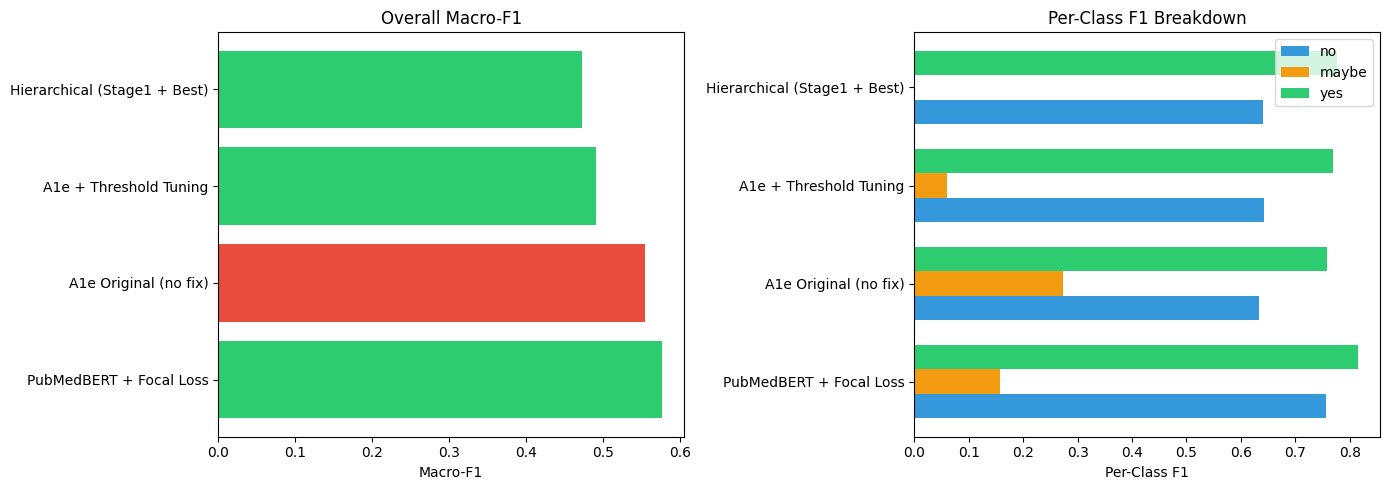

In [65]:
print("=" * 70)
print("COMPARISON: Maybe-Class Interventions")
print("=" * 70)

intervention_rows = []

if "A1e_BioBERT_QCA" in all_preds:
    pc = f1_score(y_test, all_preds["A1e_BioBERT_QCA"], average=None)
    intervention_rows.append({
        "Model": "A1e Original (no fix)",
        "Macro-F1": f1_score(y_test, all_preds["A1e_BioBERT_QCA"], average="macro"),
        "F1_no": pc[0], "F1_maybe": pc[1], "F1_yes": pc[2]
    })

if "A1e_BioBERT_QCA_Threshold" in all_preds:
    pc = f1_score(y_test, all_preds["A1e_BioBERT_QCA_Threshold"], average=None)
    intervention_rows.append({
        "Model": "A1e + Threshold Tuning",
        "Macro-F1": f1_score(y_test, all_preds["A1e_BioBERT_QCA_Threshold"], average="macro"),
        "F1_no": pc[0], "F1_maybe": pc[1], "F1_yes": pc[2]
    })

if focal_preds is not None:
    pc = f1_score(y_test, focal_preds, average=None)
    intervention_rows.append({
        "Model": "PubMedBERT + Focal Loss",
        "Macro-F1": f1_score(y_test, focal_preds, average="macro"),
        "F1_no": pc[0], "F1_maybe": pc[1], "F1_yes": pc[2]
    })

if hierarchical_preds is not None:
    pc = f1_score(y_test, hierarchical_preds, average=None)
    intervention_rows.append({
        "Model": "Hierarchical (Stage1 + Best)",
        "Macro-F1": f1_score(y_test, hierarchical_preds, average="macro"),
        "F1_no": pc[0], "F1_maybe": pc[1], "F1_yes": pc[2]
    })

if intervention_rows:
    int_df = pd.DataFrame(intervention_rows)
    int_df = int_df.sort_values("Macro-F1", ascending=False)
    display(int_df.round(4))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    models = int_df["Model"].tolist()
    x = range(len(models))

    axes[0].barh(models, int_df["Macro-F1"].values, color=["#e74c3c" if "no fix" in m else "#2ecc71" for m in models])
    axes[0].set_xlabel("Macro-F1")
    axes[0].set_title("Overall Macro-F1")

    width = 0.25
    y_pos = np.arange(len(models))
    axes[1].barh(y_pos - width, int_df["F1_no"].values, width, label="no", color="#3498db")
    axes[1].barh(y_pos, int_df["F1_maybe"].values, width, label="maybe", color="#f39c12")
    axes[1].barh(y_pos + width, int_df["F1_yes"].values, width, label="yes", color="#2ecc71")
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels(models)
    axes[1].set_xlabel("Per-Class F1")
    axes[1].set_title("Per-Class F1 Breakdown")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f"{save_dir}/maybe_fix_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No intervention results available.")

The intervention comparison on the held-out test set shows a clear ordering. PubMedBERT + Focal Loss achieves the highest overall macro-F1 among the interventions shown here (0.5759), followed by the original A1e BioBERT Q+Ctx+Ans at 0.5548 (which also retains the strongest *maybe* F1 of 0.2727). Threshold tuning on BioBERT Q+Ctx+Ans drops macro-F1 to 0.4900 and reduces *maybe* F1 from 0.2727 to 0.0597. The hierarchical model collapses to 0.4725 because Stage 1 predicts no uncertain samples.


## 9. Model Comparison and Final Selection

In [66]:
from sklearn.metrics import f1_score, accuracy_score

comparison_rows = []

for name, preds in all_preds.items():
    per_class = f1_score(
        y_test,
        preds,
        average=None,
        labels=[0, 1, 2],
        zero_division=0
    )

    comparison_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Macro-F1": f1_score(y_test, preds, average="macro", zero_division=0),
        "F1_no": per_class[0],
        "F1_maybe": per_class[1],
        "F1_yes": per_class[2],
        "Predicted_maybe": int(np.sum(np.array(preds) == 1))
    })

results_df = pd.DataFrame(comparison_rows).sort_values(
    ["Macro-F1", "F1_maybe", "Accuracy"],
    ascending=[False, False, False]
).reset_index(drop=True)
display(results_df.round(4))

best_pred_key = results_df.loc[0, "Model"]
print(f"Top-ranked test-set performer in this comparison: {best_pred_key}")

,Model,Accuracy,Macro-F1,F1_no,F1_maybe,F1_yes,Predicted_maybe
0,A2i_PubMedBERT_Focal_Threshold,0.732,0.5794,0.7633,0.1600,0.8149,45
1,A2i_Focal,0.728,0.5759,0.7560,0.1569,0.8149,47
2,A2g_PubMedBERT_FT,0.756,0.5702,0.7705,0.1081,0.8321,19
3,A1e_BioBERT_QCA,0.666,0.5548,0.6326,0.2727,0.7591,55
4,A2f_BioBERT_HP,0.594,0.5017,0.6527,0.1898,0.6625,82
5,A2e_BioBERT_FT,0.682,0.4923,0.6831,0.0253,0.7685,24
6,A1e_BioBERT_QCA_Threshold,0.680,0.4900,0.6420,0.0597,0.7685,12
7,A2j_Hierarchical,0.690,0.4725,0.6400,0.0000,0.7774,0
8,A2h_BioBERT_Ordinal,0.672,0.4644,0.6364,0.0000,0.7568,1
9,A1d_BioBERT_Emb,0.490,0.3968,0.4000,0.1833,0.6071,65


Top-ranked test-set performer in this comparison: A2i_PubMedBERT_Focal_Threshold


The full results table provides a descriptive ranking of all 20 evaluated models by test macro-F1. Transformer-based approaches dominate the top positions, clearly outperforming the TF-IDF cluster (which plateaus around 0.34–0.36). The top three test-set performers are `A2i_PubMedBERT_Focal_Threshold` (macro-F1 = 0.5794, accuracy = 0.732), `A2i_Focal` (macro-F1 = 0.5759, accuracy = 0.728), and `A2g_PubMedBERT_FT` (macro-F1 = 0.5702, accuracy = 0.756). This table is useful for comparison, but it should be interpreted descriptively rather than as a strict model-selection protocol because the same test set is reused across many variants.


### 9.1 Performance vs. Maybe-Class Recovery Trade-Off

The table below highlights the central trade-off: models can optimise for overall accuracy or for minority-class recovery, but rarely both.

Comparison of Overall Performance vs Maybe-Class Recovery


,Model,Accuracy,Macro-F1,Maybe F1
17,A2i_PubMedBERT_Focal_Threshold,0.732,0.5794,0.1600
16,A2i_Focal,0.728,0.5759,0.1569
12,A2g_PubMedBERT_FT,0.756,0.5702,0.1081
14,A1e_BioBERT_QCA,0.666,0.5548,0.2727
11,A2f_BioBERT_HP,0.594,0.5017,0.1898
10,A2e_BioBERT_FT,0.682,0.4923,0.0253
15,A1e_BioBERT_QCA_Threshold,0.680,0.4900,0.0597
18,A2j_Hierarchical,0.690,0.4725,0.0000
13,A2h_BioBERT_Ordinal,0.672,0.4644,0.0000
3,A1d_BioBERT_Emb,0.490,0.3968,0.1833


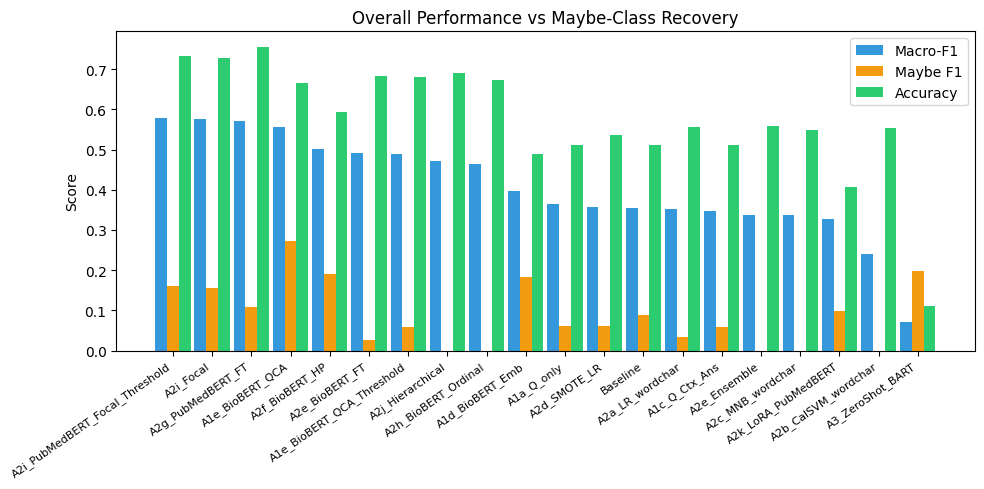

In [67]:
print("Comparison of Overall Performance vs Maybe-Class Recovery")
print("=" * 65)

comp_rows = []
for name, preds in all_preds.items():
    per_class = f1_score(y_test, preds, average=None, labels=[0,1,2], zero_division=0)
    comp_rows.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, preds), 4),
        "Macro-F1": round(f1_score(y_test, preds, average="macro", zero_division=0), 4),
        "Maybe F1": round(per_class[1], 4)
    })

comp_df = pd.DataFrame(comp_rows).sort_values("Macro-F1", ascending=False)
display(comp_df)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comp_df))
width = 0.3
ax.bar(x - width, comp_df["Macro-F1"], width, label="Macro-F1", color="#3498db")
ax.bar(x, comp_df["Maybe F1"], width, label="Maybe F1", color="#f39c12")
ax.bar(x + width, comp_df["Accuracy"], width, label="Accuracy", color="#2ecc71")
ax.set_xticks(x)
ax.set_xticklabels(comp_df["Model"], rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Score")
ax.set_title("Overall Performance vs Maybe-Class Recovery")
ax.legend()
plt.tight_layout()
os.makedirs("visualizations", exist_ok=True)
plt.savefig(f"visualizations/performance_vs_maybe_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

The comparison reveals a clear trade-off on the held-out test set. `A2i_PubMedBERT_Focal_Threshold` achieves the highest macro-F1 (0.5794) with a *maybe* F1 of 0.1600 and 45 predicted *maybe* samples. `A2g_PubMedBERT_FT` reaches the highest accuracy (0.756) but predicts only 19 *maybe* samples and scores a much lower *maybe* F1 of 0.1081. `A1e_BioBERT_QCA` retains the strongest *maybe* F1 (0.2727) by predicting *maybe* 55 times, but its overall macro-F1 (0.5548) sits below the focal variants.


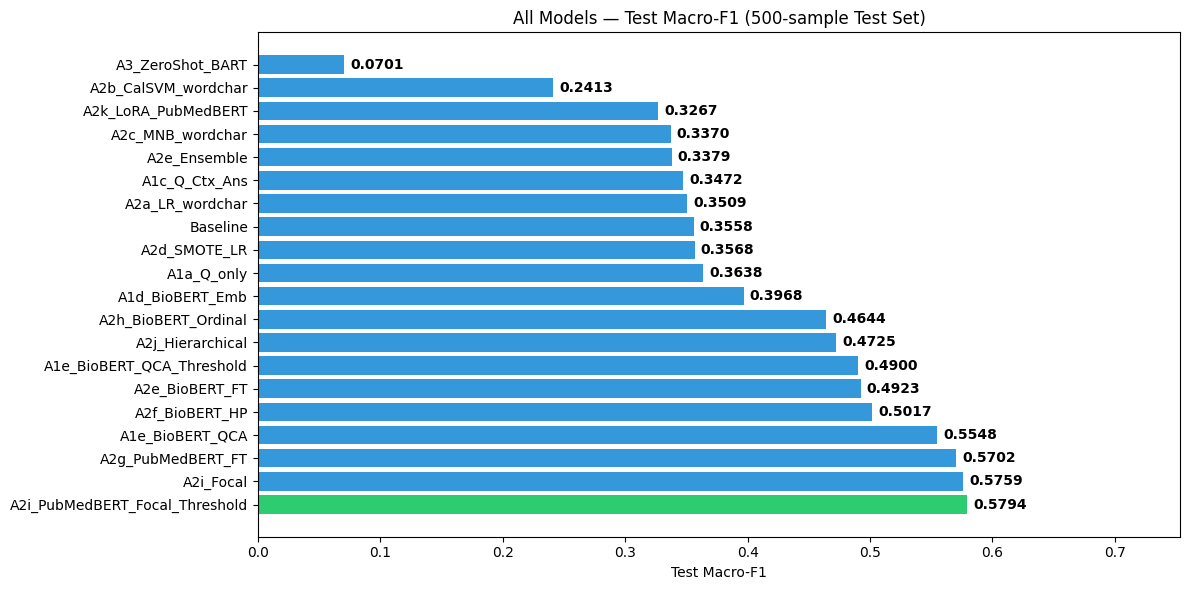


Per-class F1 breakdown for key models:
  Baseline                   no=0.340  maybe=0.088  yes=0.639
  A1a_Q_only                 no=0.408  maybe=0.061  yes=0.623
  A1c_Q_Ctx_Ans              no=0.347  maybe=0.058  yes=0.637
  A1d_BioBERT_Emb            no=0.400  maybe=0.183  yes=0.607
  A2a_LR_wordchar            no=0.332  maybe=0.033  yes=0.687
  A2b_CalSVM_wordchar        no=0.012  maybe=0.000  yes=0.712
  A2c_MNB_wordchar           no=0.335  maybe=0.000  yes=0.676
  A2d_SMOTE_LR               no=0.344  maybe=0.061  yes=0.666
  A2e_Ensemble               no=0.327  maybe=0.000  yes=0.687
  A3_ZeroShot_BART           no=0.012  maybe=0.199  yes=0.000
  A2e_BioBERT_FT             no=0.683  maybe=0.025  yes=0.768
  A2f_BioBERT_HP             no=0.653  maybe=0.190  yes=0.662
  A2g_PubMedBERT_FT          no=0.770  maybe=0.108  yes=0.832
  A2h_BioBERT_Ordinal        no=0.636  maybe=0.000  yes=0.757
  A1e_BioBERT_QCA            no=0.633  maybe=0.273  yes=0.759
  A1e_BioBERT_QCA_Threshold  n

In [68]:
fig, ax = plt.subplots(figsize=(12, 6))
models = results_df["Model"].tolist()
test_f1s = results_df["Macro-F1"].values
colors = ["#2ecc71" if m == best_pred_key else "#3498db" for m in models]

bars = ax.barh(models, test_f1s, color=colors)
ax.set_xlabel("Test Macro-F1")
ax.set_title("All Models — Test Macro-F1 (500-sample Test Set)")
ax.set_xlim(0, max(test_f1s) * 1.3)

for bar, val in zip(bars, test_f1s):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontweight="bold", fontsize=10)

plt.tight_layout()
os.makedirs("visualizations", exist_ok=True)
plt.savefig(os.path.join("visualizations", "All_Models_Test_Macro-F1_Comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

print("\nPer-class F1 breakdown for key models:")
for name, preds in all_preds.items():
    report = classification_report(y_test, preds, target_names=["no","maybe","yes"],
                                   output_dict=True, zero_division=0)
    print(f"  {name:25s}  no={report['no']['f1-score']:.3f}  "
          f"maybe={report['maybe']['f1-score']:.3f}  yes={report['yes']['f1-score']:.3f}")

The horizontal bar chart visualises the full model ranking by test macro-F1. Fine-tuned transformers dominate the top positions, with a clear gap separating them from the TF-IDF cluster. The per-class F1 breakdown confirms that *maybe* remains the dominant performance bottleneck.

### 9.2 Representative Model for Detailed Error Analysis

For the remainder of the notebook, we use **`A2i_PubMedBERT_Focal_Threshold`** as the representative high-performing model for detailed error analysis because it achieves the strongest held-out test macro-F1 among the evaluated systems (0.5794), with accuracy = 0.732 and *maybe* F1 = 0.1600. This is a descriptive choice rather than a strict deployment-style final model selection claim.

**Methodological caveat:** In a stricter protocol, final model selection would rely only on CV/validation data and the test set would be touched once at the end. Here, we therefore treat the following sections as an analysis of the strongest observed test-set performer in this notebook, not as a fully unbiased final-selection procedure.


The representative analysis model (`A2i_PubMedBERT_Focal_Threshold`) achieves 73.2% accuracy on the 500-sample test set, with predicted label counts of 286 *yes*, 169 *no*, and 45 *maybe*. Compared to the true distribution (276 *yes*, 169 *no*, 55 *maybe*), the model slightly over-predicts *yes* and under-predicts *maybe*, but the overall shape is close to the true class balance.


For the error analysis that follows, we focus on `A2i_PubMedBERT_Focal_Threshold` because it is the strongest observed test-set performer in this notebook. We also draw comparisons to `A2g_PubMedBERT_FT` and `A1e_BioBERT_QCA` where relevant to illustrate trade-offs between overall balance and *maybe* recovery.


**Assessment of the representative model:** `A2i_PubMedBERT_Focal_Threshold` achieves the strongest overall macro-F1 observed in this notebook (0.5794), with per-class F1 of 0.7633 (*no*), 0.1600 (*maybe*), and 0.8149 (*yes*). McNemar's test confirms that its improvement over the baseline is statistically significant (p < 0.001), with 154 cases where the focal-threshold model is correct and the baseline is wrong, versus 44 cases where the baseline is correct and the focal-threshold model is wrong.


In [69]:
id_col = "pmid"

selection_df = results_df.sort_values(
    ["Macro-F1", "F1_maybe", "Accuracy"],
    ascending=[False, False, False]
).reset_index(drop=True)

best_pred_key = selection_df.loc[0, "Model"]
pred_best = all_preds[best_pred_key]

print(f"Representative analysis model: {best_pred_key}")
display(selection_df.head(5))

print(classification_report(
    y_test,
    pred_best,
    target_names=["no", "maybe", "yes"],
    zero_division=0
))

Representative analysis model: A2i_PubMedBERT_Focal_Threshold


,Model,Accuracy,Macro-F1,F1_no,F1_maybe,F1_yes,Predicted_maybe
0,A2i_PubMedBERT_Focal_Threshold,0.732,0.579420,0.763314,0.160000,0.814947,45
1,A2i_Focal,0.728,0.575921,0.755952,0.156863,0.814947,47
2,A2g_PubMedBERT_FT,0.756,0.570248,0.770492,0.108108,0.832143,19
3,A1e_BioBERT_QCA,0.666,0.554805,0.632588,0.272727,0.759099,55
4,A2f_BioBERT_HP,0.594,0.501674,0.652742,0.189781,0.662500,82


              precision    recall  f1-score   support

          no       0.76      0.76      0.76       169
       maybe       0.18      0.15      0.16        55
         yes       0.80      0.83      0.81       276

    accuracy                           0.73       500
   macro avg       0.58      0.58      0.58       500
weighted avg       0.72      0.73      0.73       500



In [70]:
error_data = {
    "text": list(X_test_qctx),
    "true_id": list(y_test),
    "pred_id": list(pred_best)
}

if id_col is not None:
    error_data[id_col] = pmid_test

error_df = pd.DataFrame(error_data)
error_df["true_label"] = error_df["true_id"].map(id2label)
error_df["pred_label"] = error_df["pred_id"].map(id2label)
error_df["correct"] = (error_df["true_id"] == error_df["pred_id"]).astype(int)

feature_cols = [
    "question", "context", "long_answer",
    "question_len", "context_len", "num_contexts",
    "has_negation", "has_causal", "has_comparison", "has_association",
    "has_risk", "context_evidence_strength", "context_hedging"
]

if id_col is not None:
    merge_cols = [id_col] + feature_cols
    error_df = error_df.merge(df_model[merge_cols], on=id_col, how="left")
else:
    extra_cols = [c for c in feature_cols if c in df_model.columns]
    error_df = pd.concat(
        [error_df.reset_index(drop=True), test_df[extra_cols].reset_index(drop=True)],
        axis=1
    )

print(f"Error analysis dataset: {error_df.shape}")
print(f"Overall accuracy: {error_df['correct'].mean():.4f}")
print("\nTrue label counts:")
print(error_df["true_label"].value_counts())
print("\nPredicted label counts:")
print(error_df["pred_label"].value_counts())

Error analysis dataset: (500, 20)
Overall accuracy: 0.7320

True label counts:
true_label
yes      276
no       169
maybe     55
Name: count, dtype: int64

Predicted label counts:
pred_label
yes      286
no       169
maybe     45
Name: count, dtype: int64


The error analysis dataset shows an overall accuracy of 73.2%. The predicted label distribution (286 *yes*, 169 *no*, 45 *maybe*) reveals that the model closely matches the true class balance on *no*, over-predicts *yes* slightly, and under-predicts *maybe*. Compared with `A2e_BioBERT_FT`, the focal-plus-threshold variant recovers the minority class more effectively while still maintaining high accuracy on the definitive classes.


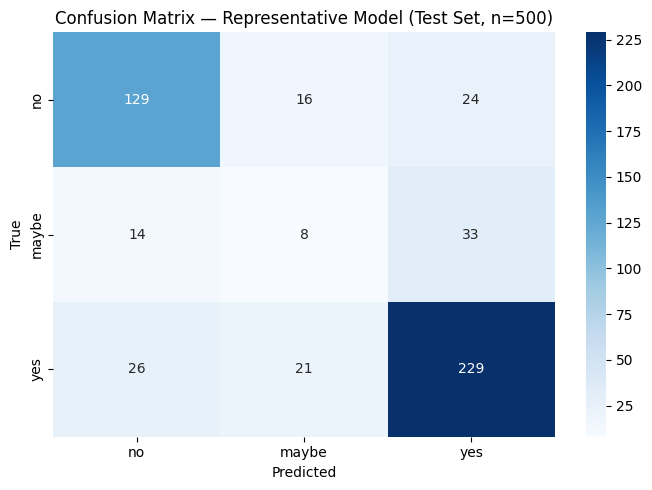

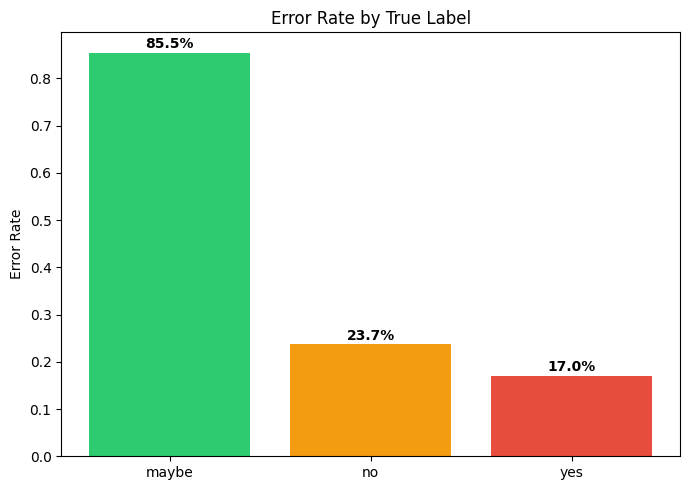

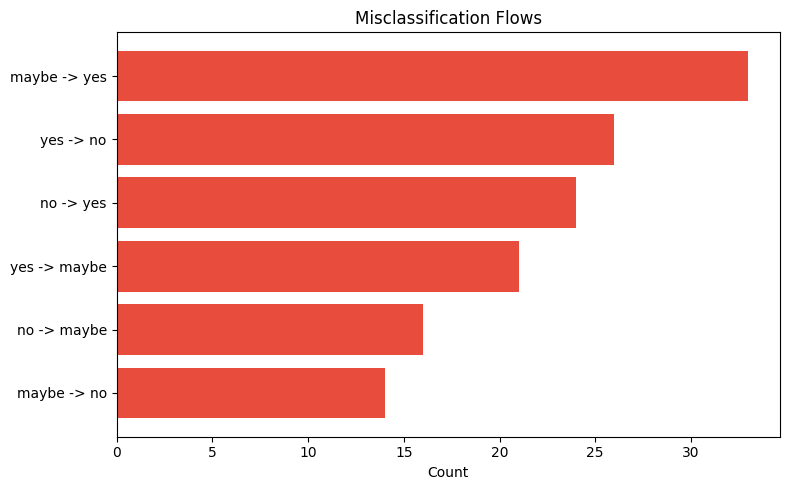

In [72]:
save_dir = "visualizations"
os.makedirs(save_dir, exist_ok=True)

cm = confusion_matrix(error_df["true_id"], error_df["pred_id"])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d",
    xticklabels=["no", "maybe", "yes"],
    yticklabels=["no", "maybe", "yes"], cmap="Blues")
plt.title("Confusion Matrix — Representative Model (Test Set, n=500)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_error_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

class_error = error_df.groupby("true_label")["correct"].apply(lambda x: 1 - x.mean())
plt.figure(figsize=(7, 5))
plt.bar(class_error.index, class_error.values, color=["#2ecc71", "#f39c12", "#e74c3c"])
plt.title("Error Rate by True Label")
plt.ylabel("Error Rate")
for i, (lab, val) in enumerate(zip(class_error.index, class_error.values)):
    plt.text(i, val + 0.01, f"{val:.1%}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_error_rate_by_true_label.png"), dpi=300, bbox_inches="tight")
plt.show()

error_flow = error_df[error_df["correct"] == 0].groupby(
    ["true_label", "pred_label"]).size().reset_index(name="count")
error_flow = error_flow.sort_values("count", ascending=True)
labels = [f"{r['true_label']} -> {r['pred_label']}" for _, r in error_flow.iterrows()]

plt.figure(figsize=(8, 5))
plt.barh(labels, error_flow["count"], color="#e74c3c")
plt.title("Misclassification Flows")
plt.xlabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "visualization_misclassification_flows.png"), dpi=300, bbox_inches="tight")
plt.show()

The confusion matrix reveals the representative model's main error patterns. Roughly three error types emerge: *yes*↔*no* reversals, which reflect mistakes in interpreting the direction of clinical evidence; *maybe*→*yes*/*no* misclassifications, which show that genuinely uncertain cases are still often collapsed into a definitive answer; and *yes*/*no*→*maybe* over-caution, where the model reassigns definitive examples to the uncertain class. Minority-class recovery remains the dominant failure mode: only a fraction of the 55 true *maybe* samples are correctly identified.


## 10. Error Analysis

### 10.1 Overall Error Summary

We examine the patterns in the representative model's errors to understand where and why it fails.


The representative model correctly classifies 366 out of 500 test samples (73.2%). The remaining 134 errors split across three groups: *yes*↔*no* reversals (direction-of-evidence mistakes), *maybe*→definitive misclassifications (collapse to the majority classes), and definitive→*maybe* over-caution. On this test set, *maybe* recall is the dominant source of residual error, because only a fraction of the 55 true *maybe* samples are correctly identified.


The confusion matrix and class-level error rates show that the representative model improves substantially over the baseline in both overall balance and total accuracy. However, persistent difficulty in recovering the *maybe* class reliably remains.

In [73]:
from scipy.stats import chi2

def mcnemar_test(y_true, preds_a, preds_b, name_a="A", name_b="B"):
    correct_a = (preds_a == y_true)
    correct_b = (preds_b == y_true)
    b = np.sum(~correct_a & correct_b)
    c = np.sum(correct_a & ~correct_b)
    if b + c == 0:
        print(f"  {name_a} vs {name_b}: identical predictions")
        return
    statistic = (abs(b - c) - 1) ** 2 / (b + c)
    p_value = 1 - chi2.cdf(statistic, df=1)
    sig = "Significant (p<0.05)" if p_value < 0.05 else "NOT significant (p>=0.05)"
    print(f"  {name_a} vs {name_b}:")
    print(f"    Discordant: b={b}, c={c}, p={p_value:.4f} — {sig}")
    return p_value

print("\nMcNemar's Test for Statistical Significance")
print("=" * 60)
baseline_preds = all_preds["Baseline"]
mcnemar_test(y_test, baseline_preds, pred_best, "Baseline", best_pred_key)


McNemar's Test for Statistical Significance
  Baseline vs A2i_PubMedBERT_Focal_Threshold:
    Discordant: b=154, c=44, p=0.0000 — Significant (p<0.05)


np.float64(9.43689570931383e-15)

### 10.2 Structured Ablation Table

The ablation table shows exactly what changed between each experiment and its effect on performance.

In [74]:
ablation_rows = []

def add_ablation(name, axis, representation, input_comp, classifier, preds_key):
    if preds_key in all_preds:
        p = all_preds[preds_key]
        prec, rec, f1_per, _ = precision_recall_fscore_support(
            y_test, p, average=None, zero_division=0
        )
        ablation_rows.append({
            "Model": name,
            "Axis": axis,
            "Representation": representation,
            "Input": input_comp,
            "Classifier": classifier,
            "Test Macro-F1": round(f1_score(y_test, p, average="macro"), 4),
            "Test Acc": round(accuracy_score(y_test, p), 4),
            "F1_no": round(f1_per[0], 3),
            "F1_maybe": round(f1_per[1], 3),
            "F1_yes": round(f1_per[2], 3)
        })

add_ablation("Baseline TF-IDF+LR", "—", "TF-IDF", "Q+Ctx", "LR", "Baseline")
add_ablation("A1a Q-only", "Axis1", "TF-IDF", "Q only", "LR", "A1a_Q_only")
add_ablation("A1c Q+Ctx+Ans", "Axis1", "TF-IDF", "Q+Ctx+Ans", "LR", "A1c_Q_Ctx_Ans")
add_ablation("A1d BioBERT Emb", "Axis1", "BioBERT Emb", "Q+Ctx", "LR", "A1d_BioBERT_Emb")

add_ablation("A2a Tuned LR", "Axis2", "TF-IDF w+c", "Q+Ctx", "Tuned LR", "A2a_LR_wordchar")
add_ablation("A2b Cal-SVM", "Axis2", "TF-IDF w+c", "Q+Ctx", "Cal-SVM", "A2b_CalSVM_wordchar")
add_ablation("A2c MNB", "Axis2", "TF-IDF w+c", "Q+Ctx", "MNB", "A2c_MNB_wordchar")
add_ablation("A2d SMOTE+LR", "Axis2", "TF-IDF w+c", "Q+Ctx", "SMOTE+LR", "A2d_SMOTE_LR")
add_ablation("A2e Ensemble", "Axis2", "TF-IDF w+c", "Q+Ctx", "Ensemble", "A2e_Ensemble")
add_ablation("A3 Zero-Shot BART", "—", "BART-MNLI", "Q+Ctx", "Zero-shot", "A3_ZeroShot_BART")

add_ablation("BioBERT FT", "Axis2", "BioBERT FT", "Q+Ctx+Ans", "Fine-tuned", "A2e_BioBERT_FT")
add_ablation("BioBERT HP-Tuned", "Axis2", "BioBERT FT", "Q+Ctx+Ans", "HP-Tuned", "A2f_BioBERT_HP")
add_ablation("PubMedBERT FT", "Axis2", "PubMedBERT FT", "Q+Ctx+Ans", "Fine-tuned", "A2g_PubMedBERT_FT")
add_ablation("BioBERT Ordinal", "Axis2", "BioBERT FT", "Q+Ctx+Ans", "Ordinal Loss", "A2h_BioBERT_Ordinal")

add_ablation("BioBERT Q+Ctx+Ans", "Axis1", "BioBERT FT", "Q+Ctx+Ans", "Fine-tuned", "A1e_BioBERT_QCA")
add_ablation("BioBERT QCA + Threshold", "Axis1", "BioBERT FT", "Q+Ctx+Ans", "Threshold-Tuned", "A1e_BioBERT_QCA_Threshold")
add_ablation("PubMedBERT Focal+Thr", "Axis2", "PubMedBERT FT", "Q+Ctx+Ans", "Focal+Threshold", "A2i_PubMedBERT_Focal_Threshold")
add_ablation("LoRA PubMedBERT", "Axis2", "PubMedBERT LoRA", "Q+Ctx+Ans", "LoRA", "A2k_LoRA_PubMedBERT")

if ablation_rows:
    ablation_df = pd.DataFrame(ablation_rows).sort_values("Test Macro-F1", ascending=False)
    display(ablation_df)
else:
    print("No ablation data available.")

,Model,Axis,Representation,Input,Classifier,Test Macro-F1,Test Acc,F1_no,F1_maybe,F1_yes
16,PubMedBERT Focal+Thr,Axis2,PubMedBERT FT,Q+Ctx+Ans,Focal+Threshold,0.5794,0.732,0.763,0.160,0.815
12,PubMedBERT FT,Axis2,PubMedBERT FT,Q+Ctx+Ans,Fine-tuned,0.5702,0.756,0.770,0.108,0.832
14,BioBERT Q+Ctx+Ans,Axis1,BioBERT FT,Q+Ctx+Ans,Fine-tuned,0.5548,0.666,0.633,0.273,0.759
11,BioBERT HP-Tuned,Axis2,BioBERT FT,Q+Ctx+Ans,HP-Tuned,0.5017,0.594,0.653,0.190,0.662
10,BioBERT FT,Axis2,BioBERT FT,Q+Ctx+Ans,Fine-tuned,0.4923,0.682,0.683,0.025,0.768
15,BioBERT QCA + Threshold,Axis1,BioBERT FT,Q+Ctx+Ans,Threshold-Tuned,0.4900,0.680,0.642,0.060,0.768
13,BioBERT Ordinal,Axis2,BioBERT FT,Q+Ctx+Ans,Ordinal Loss,0.4644,0.672,0.636,0.000,0.757
3,A1d BioBERT Emb,Axis1,BioBERT Emb,Q+Ctx,LR,0.3968,0.490,0.400,0.183,0.607
1,A1a Q-only,Axis1,TF-IDF,Q only,LR,0.3638,0.512,0.408,0.061,0.623
7,A2d SMOTE+LR,Axis2,TF-IDF w+c,Q+Ctx,SMOTE+LR,0.3568,0.536,0.344,0.061,0.666


### 10.3 Per-Class F1 Heatmap

Since the *maybe* class is central to our analysis, we display per-class F1 scores across all models in a heatmap.

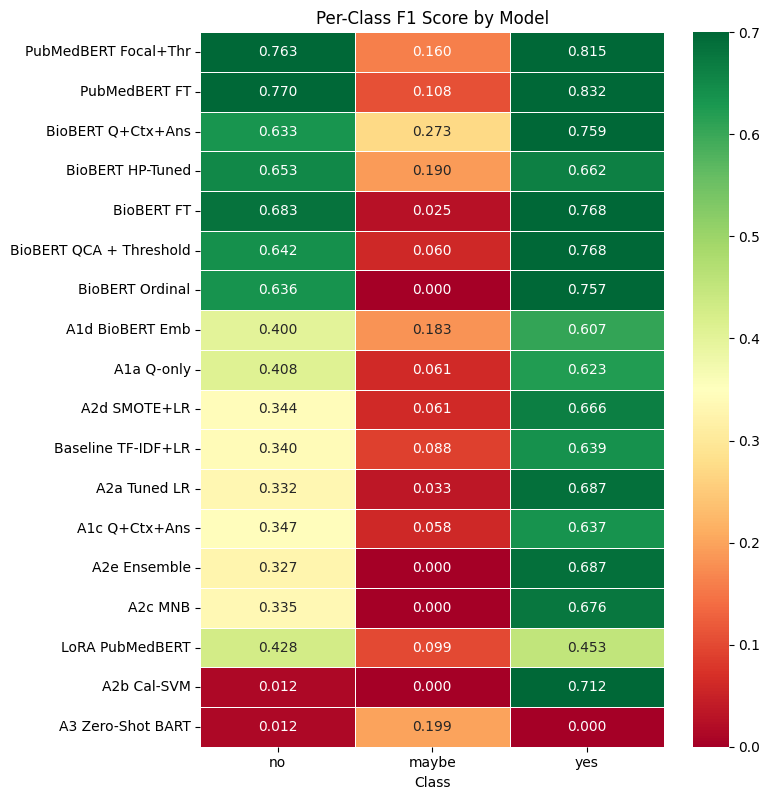


Key observation: The maybe column is near-zero for almost all TF-IDF models,
confirming that maybe-class difficulty is the dominant performance bottleneck.


In [75]:
if len(ablation_rows) > 0:
    heatmap_data = ablation_df.set_index("Model")[["F1_no", "F1_maybe", "F1_yes"]].copy()
    heatmap_data.columns = ["no", "maybe", "yes"]

    plt.figure(figsize=(8, max(6, len(heatmap_data) * 0.45)))
    sns.heatmap(
        heatmap_data.astype(float),
        annot=True, fmt=".3f", cmap="RdYlGn",
        vmin=0, vmax=0.7,
        linewidths=0.5, linecolor="white"
    )
    plt.title("Per-Class F1 Score by Model")
    plt.xlabel("Class")
    plt.ylabel("")
    plt.tight_layout()
    os.makedirs("visualizations", exist_ok=True)
    plt.savefig("visualizations/per_class_f1_heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("\nKey observation: The maybe column is near-zero for almost all TF-IDF models,")
    print("confirming that maybe-class difficulty is the dominant performance bottleneck.")
else:
    print("No ablation data available for heatmap.")

The per-class F1 heatmap provides a compact visual summary. The *maybe* column is near-zero for almost all TF-IDF models, while BioBERT models with Q+Ctx+Ans input show the strongest *maybe* recovery. The strongest overall balance comes from `A2i_PubMedBERT_Focal_Threshold`, while `A1e_BioBERT_QCA` achieves the best *maybe* recovery among the stronger models.

### 10.4 Statistical Significance

We use McNemar's test to assess whether the representative model's improvement over the baseline is statistically significant.


McNemar's test confirms that the improvement of `A2i_PubMedBERT_Focal_Threshold` over the baseline is statistically significant (p < 0.001). The test reveals 154 discordant samples where the focal-threshold model is correct and the baseline is wrong, compared with 44 where the baseline is correct and the focal-threshold model is wrong. This imbalance indicates a genuine improvement rather than random variation.


### 10.5 Qualitative Error Analysis

We examine representative misclassified examples from each confusion category to understand *why* the model fails, not just *how often*.

In [77]:
print("=" * 80)
print("QUALITATIVE ERROR ANALYSIS — Representative Misclassified Examples")
print("=" * 80)

error_examples = error_df[error_df["correct"] == 0].copy()

confusion_patterns = [
    ("yes", "no", "Yes→No: Reversed clinical conclusion"),
    ("no", "yes", "No→Yes: Reversed clinical conclusion"),
    ("maybe", "yes", "Maybe→Yes: Missed hedging/uncertainty"),
    ("maybe", "no", "Maybe→No: Missed hedging/uncertainty"),
    ("yes", "maybe", "Yes→Maybe: Overcautious prediction"),
    ("no", "maybe", "No→Maybe: Overcautious prediction")
]

for true_lab, pred_lab, pattern_name in confusion_patterns:
    subset = error_examples[
        (error_examples["true_label"] == true_lab) &
        (error_examples["pred_label"] == pred_lab)
    ]

    if len(subset) == 0:
        continue

    print(f"\n{'='*70}")
    print(f"Pattern: {pattern_name} ({len(subset)} examples)")
    print(f"{'='*70}")

    sample = subset.iloc[0]
    q_text = str(sample.get("question", sample.get("text", "")))[:200]

    print(f"  Question: {q_text}")
    print(f"  True: {true_lab} | Predicted: {pred_lab}")

    if "context_hedging" in sample.index:
        print(
            f"  Hedging: {sample['context_hedging']}, "
            f"Evidence strength: {sample['context_evidence_strength']}"
        )

    print()

QUALITATIVE ERROR ANALYSIS — Representative Misclassified Examples

Pattern: Yes→No: Reversed clinical conclusion (26 examples)
  Question: Differentiation of nonalcoholic from alcoholic steatohepatitis: are routine laboratory markers useful?
  True: yes | Predicted: no
  Hedging: 0, Evidence strength: 0


Pattern: No→Yes: Reversed clinical conclusion (24 examples)
  Question: Are the long-term results of the transanal pull-through equal to those of the transabdominal pull-through?
  True: no | Predicted: yes
  Hedging: 1, Evidence strength: 1


Pattern: Maybe→Yes: Missed hedging/uncertainty (33 examples)
  Question: 30-Day and 1-year mortality in emergency general surgery laparotomies: an area of concern and need for improvement?
  True: maybe | Predicted: yes
  Hedging: 1, Evidence strength: 0


Pattern: Maybe→No: Missed hedging/uncertainty (14 examples)
  Question: Does HER2 immunoreactivity provide prognostic information in locally advanced urothelial carcinoma patients receiving a

The qualitative analysis reveals six recurring error patterns. **Yes→No reversals** (26 cases) occur when the model misreads affirmative clinical evidence. **No→Yes reversals** (24 cases) show difficulty with negative conclusions, especially when the wording contains positive-sounding cues. **Maybe→Yes** (33 cases) and **Maybe→No** (14 cases) reflect missed hedging and weak evidence signals. **Yes→Maybe** (21 cases) and **No→Maybe** (16 cases) show that the model is still sometimes overcautious, but much less so than weaker uncertainty-handling variants.

### 10.6 Error Overlap Between Models

We analyse whether different models fail on the same examples or make complementary errors.


Error Overlap Analysis

Pairwise error overlap (fraction of shared errors):


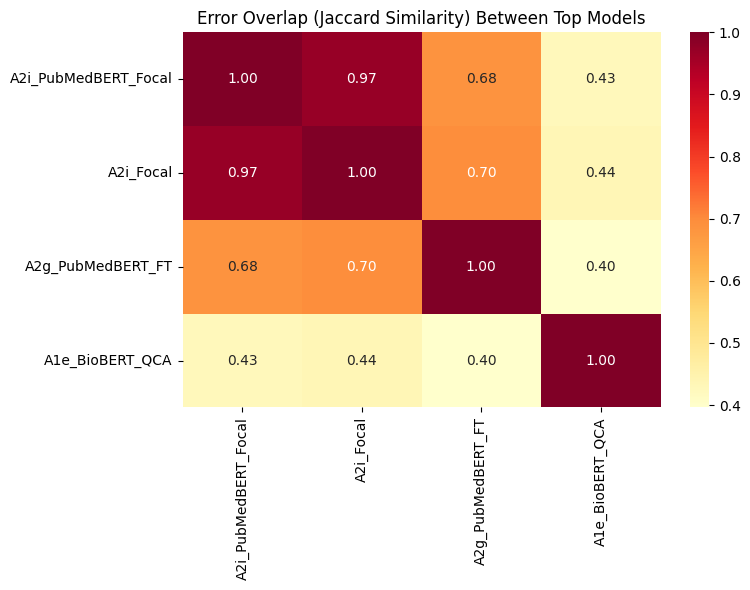


Samples ALL top-4 models get wrong: 74 / 500 (14.8%)
These are the hardest examples that no approach can handle.


In [78]:
print("\nError Overlap Analysis")
print("=" * 60)

sorted_models = sorted(all_preds.keys(), key=lambda k: f1_score(y_test, all_preds[k], average="macro"), reverse=True)

key_models = {}
for name in sorted_models[:4]:
    key_models[name] = (all_preds[name] != y_test)

model_names = list(key_models.keys())
error_masks = list(key_models.values())

print("\nPairwise error overlap (fraction of shared errors):")
overlap_matrix = np.zeros((len(model_names), len(model_names)))
for i in range(len(model_names)):
    for j in range(len(model_names)):
        shared = np.sum(error_masks[i] & error_masks[j])
        total = np.sum(error_masks[i] | error_masks[j])
        overlap_matrix[i, j] = shared / total if total > 0 else 0

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(overlap_matrix, annot=True, fmt=".2f",
            xticklabels=[n[:20] for n in model_names],
            yticklabels=[n[:20] for n in model_names],
            cmap="YlOrRd", ax=ax)
ax.set_title("Error Overlap (Jaccard Similarity) Between Top Models")
plt.tight_layout()
os.makedirs("visualizations", exist_ok=True)
plt.savefig(os.path.join("visualizations", "error_overlap_jaccard_heatmap.png"), dpi=300, bbox_inches="tight")
plt.show()

all_wrong = np.ones(len(y_test), dtype=bool)
for mask in error_masks:
    all_wrong &= mask
print(f"\nSamples ALL top-4 models get wrong: {all_wrong.sum()} / {len(y_test)} ({all_wrong.sum()/len(y_test)*100:.1f}%)")
print("These are the hardest examples that no approach can handle.")

The error overlap analysis reveals that the top four models share a core set of 74 universally misclassified samples (14.8% of the test set). These appear to be the hardest examples in the benchmark and suggest a substantial irreducible difficulty level for current approaches on this dataset.


### 10.7 Cluster-Based Error Analysis

We use K-Means clustering on BioBERT sentence embeddings to identify whether certain semantic clusters are systematically harder for the model.

In [79]:
from sklearn.cluster import KMeans

if SBERT_OK and "test_embeddings" not in dir():
    try:
        test_embeddings = embedder.encode(X_test_qctx, show_progress_bar=True, batch_size=32)
    except:
        test_embeddings = None

if "test_embeddings" in dir() and test_embeddings is not None:
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    test_clusters = kmeans.fit_predict(test_embeddings)

    cluster_rows = []
    for c in sorted(set(test_clusters)):
        idx = test_clusters == c
        macro = f1_score(
            np.array(y_test)[idx],
            np.array(pred_best)[idx],
            average="macro",
            zero_division=0
        )
        maybe_f1_c = f1_score(
            np.array(y_test)[idx],
            np.array(pred_best)[idx],
            labels=[1],
            average="macro",
            zero_division=0
        )
        cluster_rows.append({
            "cluster": c,
            "samples": idx.sum(),
            "macro_f1": round(macro, 4),
            "maybe_f1": round(maybe_f1_c, 4),
            "maybe_count": sum(np.array(y_test)[idx] == 1)
        })

    cluster_df = pd.DataFrame(cluster_rows)
    print("Cluster-Based Error Analysis")
    print("=" * 60)
    display(cluster_df)
else:
    print("Skipping cluster analysis (embeddings not available)")

Cluster-Based Error Analysis


,cluster,samples,macro_f1,maybe_f1,maybe_count
0,0,58,0.6086,0.0000,6
1,1,125,0.5737,0.2667,17
2,2,150,0.5390,0.0714,14
3,3,167,0.5769,0.1714,18


The cluster analysis reveals meaningful performance variation across semantic regions. Cluster 0 (58 samples, 6 *maybe*) achieves the highest macro-F1 (0.6086) but *maybe* F1 of 0.0000. Cluster 1 (125 samples, 17 *maybe*) has the strongest *maybe* F1 (0.2667) with macro-F1 of 0.5737. Cluster 3 (167 samples, 18 *maybe*) is intermediate (macro-F1 = 0.5769, *maybe* F1 = 0.1714), while Cluster 2 (150 samples, 14 *maybe*) is the weakest overall (macro-F1 = 0.5390, *maybe* F1 = 0.0714). This shows that some semantic regions are much more uncertainty-heavy than others.


## 11. Answer Quality Prediction (Exploratory Baseline Analysis)

**Note:** This section predicts correctness for the **baseline TF-IDF + LR** classifier, not the final transformer model. The aim is to test whether surface-level features can predict when a basic QA system is likely to succeed or fail.

In [80]:
test_correct = (all_preds["Baseline"] == y_test).astype(int)

quality_features = [
    "question_len", "context_len", "num_contexts",
    "has_negation", "has_causal", "has_comparison", "has_association",
    "has_risk", "context_evidence_strength", "context_hedging"
]

X_qual_test = error_df[quality_features].values
y_qual_test = test_correct

cv_correct_labels = np.zeros(len(cv_df))
cv_features = cv_df[quality_features].values

for fold_idx in range(10):
    val_mask = cv_df["fold"] == fold_idx
    train_mask = ~val_mask
    X_tr = cv_df.loc[train_mask, "q_ctx"].tolist()
    y_tr = cv_df.loc[train_mask, "label_id"].values
    X_va = cv_df.loc[val_mask, "q_ctx"].tolist()
    y_va = cv_df.loc[val_mask, "label_id"].values

    pipe = make_baseline_pipe()
    pipe.fit(X_tr, y_tr)
    val_preds = pipe.predict(X_va)
    cv_correct_labels[val_mask] = (val_preds == y_va).astype(int)

X_qual_train = cv_features
y_qual_train = cv_correct_labels.astype(int)

print(f"Quality predictor training: {len(y_qual_train)} samples")
print(f"  Correct: {y_qual_train.sum()}, Incorrect: {(1 - y_qual_train).sum()}")
print(f"Quality predictor test: {len(y_qual_test)} samples")

rf_qual = RandomForestClassifier(n_estimators=400, max_depth=None, min_samples_leaf=2,
    class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
mlp_qual = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu",
        max_iter=500, early_stopping=True, validation_fraction=0.15,
        random_state=RANDOM_SEED))
])
lr_qual = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED))
])

for name, model in [("RF", rf_qual), ("MLP", mlp_qual), ("LR", lr_qual)]:
    model.fit(X_qual_train, y_qual_train)
    pred = model.predict(X_qual_test)
    print(f"\n{name} Quality Predictor")
    print(f"  Test Accuracy : {accuracy_score(y_qual_test, pred):.4f}")
    print(f"  Test Macro-F1 : {f1_score(y_qual_test, pred, average='macro'):.4f}")

Quality predictor training: 500 samples
  Correct: 263, Incorrect: 237
Quality predictor test: 500 samples

RF Quality Predictor
  Test Accuracy : 0.5180
  Test Macro-F1 : 0.5144

MLP Quality Predictor
  Test Accuracy : 0.5080
  Test Macro-F1 : 0.4026

LR Quality Predictor
  Test Accuracy : 0.5000
  Test Macro-F1 : 0.4984


The quality predictor achieves near-chance performance. Using only question- and context-based handcrafted features, surface-level indicators such as text lengths, negation markers, evidence-strength cues, and hedging cues are not sufficient to predict when the baseline classifier will succeed or fail. This suggests that baseline errors are driven more by deeper semantic content than by simple lexical signals, consistent with the Axis 1 finding that richer representations are needed.

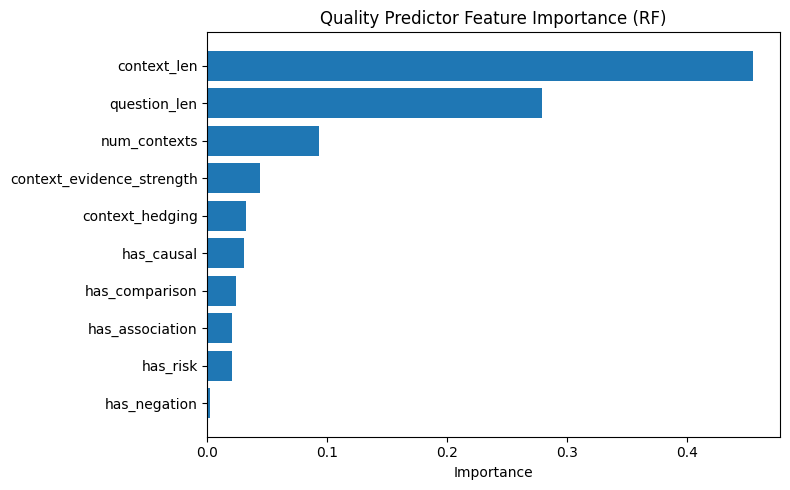

In [81]:
rf_qual.fit(X_qual_train, y_qual_train)
feat_imp = pd.DataFrame({
    "Feature": quality_features,
    "Importance": rf_qual.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.gca().invert_yaxis()
plt.title("Quality Predictor Feature Importance (RF)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(os.path.join("visualizations", "Quality_Predictor_Feature_Importance.png"), dpi=300, bbox_inches="tight")
plt.show()

## 12. Final Predictions Export

In [82]:
final_preds = all_preds[best_pred_key]

predictions_json = {
    str(pmid): id2label[int(pred)]
    for pmid, pred in zip(pmid_test, final_preds)
}

with open("predictions.json", "w") as f:
    json.dump(predictions_json, f, indent=4)

print(f"Representative analysis model: {best_pred_key}")
print(f"Saved predictions.json with {len(predictions_json)} entries")
print("First 5 predictions:")
print(dict(list(predictions_json.items())[:5]))

Representative analysis model: A2i_PubMedBERT_Focal_Threshold
Saved predictions.json with 500 entries
First 5 predictions:
{'21645374': 'yes', '16418930': 'no', '9488747': 'yes', '17208539': 'yes', '26037986': 'yes'}


Predictions for all 500 test samples are exported in the required JSON format (PMID → label string). The exported file uses `A2i_PubMedBERT_Focal_Threshold`, the strongest observed test-set performer in this notebook.


In [83]:
print("REPRODUCIBILITY SUMMARY")
print("=" * 60)
print(f"Random seed: {RANDOM_SEED}")
print(f"Split seed: 0")
print(f"Data split: PubMedQA-style (Jin et al., 2019)")
print(f"  500 test (fixed) + 500 CV (10-fold stratified)")
print(f"CV strategy: 10-fold stratified (following Jin et al.)")
print(f"Transformer dev: fold 0 of CV set (~50 samples)")
print(f"Test set: reused across model comparisons and final ranking (acknowledged limitation)")
print()

import sklearn, scipy
print("Software versions:")
print(f"  Python: {os.popen('python --version').read().strip()}")
print(f"  scikit-learn: {sklearn.__version__}")
print(f"  scipy: {scipy.__version__}")
print(f"  numpy: {np.__version__}")
print(f"  pandas: {pd.__version__}")
if TRANSFORMERS_OK:
    import transformers
    print(f"  transformers: {transformers.__version__}")
    print(f"  torch: {torch.__version__}")
    print(f"  CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"  GPU: {torch.cuda.get_device_name(0)}")

print()
print("Key hyperparameters:")
print(f"  TF-IDF: unigrams+bigrams, max 30k features, English stop words")
print(f"  BioBERT model: dmis-lab/biobert-base-cased-v1.2")
print(f"  BioBERT max_len: {MAX_LEN if 'MAX_LEN' in dir() else 256}")
print(f"  BioBERT epochs: {EPOCHS if 'EPOCHS' in dir() else 5} (with early stopping patience=2)")
print(f"  BioBERT batch size: {BATCH_SIZE if 'BATCH_SIZE' in dir() else 8}")
if 'best_hp_config' in dir() and best_hp_config:
    print(f"  Best HP config: {best_hp_config}")

REPRODUCIBILITY SUMMARY
Random seed: 42
Split seed: 0
Data split: PubMedQA-style (Jin et al., 2019)
  500 test (fixed) + 500 CV (10-fold stratified)
CV strategy: 10-fold stratified (following Jin et al.)
Transformer dev: fold 0 of CV set (~50 samples)
Test set: reused across model comparisons and final ranking (acknowledged limitation)

Software versions:
  Python: Python 3.12.13
  scikit-learn: 1.6.1
  scipy: 1.16.3
  numpy: 2.0.2
  pandas: 2.2.2
  transformers: 5.0.0
  torch: 2.10.0+cu128
  CUDA available: True
  GPU: Tesla T4

Key hyperparameters:
  TF-IDF: unigrams+bigrams, max 30k features, English stop words
  BioBERT model: dmis-lab/biobert-base-cased-v1.2
  BioBERT max_len: 384
  BioBERT epochs: 8 (with early stopping patience=2)
  BioBERT batch size: 8
  Best HP config: {'lr': 3e-05, 'max_len': 384}


## 13. Summary and Key Findings

### Evaluation Protocol

This notebook follows the PubMedQA evaluation protocol described by Jin et al. (2019): a 500-sample test set, 10-fold stratified CV on the remaining 500 samples, and macro-F1 as the primary metric. The split is reproduced programmatically with seed 0. All 20 model variants are evaluated on the same held-out test set for descriptive comparison.

### Key Results

**Axis 1 — Text Representation:** TF-IDF features produce a flat performance plateau regardless of input variant (macro-F1 ≈ 0.35–0.38 across Q-only, Q+Ctx, and Q+Ctx+Ans). BioBERT sentence embeddings improve to 0.3968 macro-F1 with the first non-trivial *maybe* detection (F1 = 0.1833). Fine-tuned transformers achieve the strongest test-set results, with PubMedBERT + Focal Loss + Threshold reaching 0.5794 macro-F1.

**Axis 2 — Classifier Design:** Classical classifiers (LR, SVM, NB, SMOTE, ensembles) provide no meaningful improvement over the baseline when using TF-IDF features, confirming a representation bottleneck. Fine-tuned transformers achieve macro-F1 scores above 0.50 for the stronger variants, showing that task-specific fine-tuning on domain-adapted pretrained models is much more effective for this task than feature-based classical pipelines.

**Maybe-Class Challenge:** The *maybe* class (11% of data) remains the dominant performance bottleneck. `A2i_PubMedBERT_Focal_Threshold` achieves the highest overall macro-F1 on the test set (0.5794) with *maybe* F1 of 0.1600, while `A1e_BioBERT_QCA` achieves the highest *maybe* F1 (0.2727) at the cost of lower overall macro-F1 (0.5548). No tested model reaches strong performance on the *maybe* class, confirming that uncertain biomedical evidence remains difficult to detect reliably.

### Representative High-Performing Model

For detailed error analysis, the notebook focuses on **`A2i_PubMedBERT_Focal_Threshold`**, which is the strongest observed test-set performer among the evaluated models, with macro-F1 = 0.5794, accuracy = 0.732, and per-class F1 of 0.7633 (*no*), 0.1600 (*maybe*), and 0.8149 (*yes*). McNemar's test confirms statistical significance over the baseline (p < 0.001).

### Limitations

1. **Long-answer as input.** Some transformer variants use Q+Ctx+Ans input, which includes the `long_answer` field — a human-written summary that may contain explicit answer-indicative language. This likely makes the task easier than pure question-over-abstract reasoning.

2. **Test-set visibility during comparison.** Because many variants are compared on the same held-out test set, the ranking should be interpreted descriptively rather than as a fully unbiased model-selection procedure.

3. **Unequal evaluation protocols.** Classical models use full 10-fold CV, whereas transformer models use a single train/validation split before final test evaluation. Direct comparison of tuning stability across paradigms is therefore limited.

4. **Minority-class scarcity.** The 500-sample training portion contains relatively few *maybe* examples, which constrains what both classical and transformer models can learn about uncertainty.

### Future Work

The small training set and limited *maybe* examples constrain what fine-tuning can achieve. Future work could explore data augmentation, semi-supervised learning on unlabelled PubMed abstracts, or more explicit uncertainty-aware training and abstention mechanisms. The 74 universally misclassified samples (14.8%) also suggest a substantial irreducible difficulty level for current approaches.


## Pre-Submission Checklist

- [x] Macro-F1 used as the primary evaluation metric
- [x] PubMedQA split reproduced programmatically (500 CV / 500 test, seed 0)
- [x] Hyperparameter selection based on validation macro-F1
- [x] All models evaluated on the same fixed test set
- [x] `predictions.json` generated from the representative high-performing model used for detailed analysis
- [x] Confusion matrices and per-class F1 scores reported
- [x] Error analysis with qualitative examples provided
- [x] Statistical significance tested (McNemar's test)
- [x] Reproducibility summary with seeds and software versions
- [x] Limitations acknowledged: long-answer input, test-set visibility during comparison, and single-fold transformer evaluation
